# Fed-SSL cross-device — figuras em barras

Notebook **somente de leitura**. Não treina, não escreve em `results/`.

Mesmos números de `fedssl_cross_device_avaliation.ipynb`, em **barras** e com duas
leituras de cada resultado:

- **por encoder** — uma figura por encoder, barras agrupadas ao longo do regime de rótulos;
- **por regime** — uma figura por regime de rótulos, barras agrupadas ao longo dos encoders.

**A métrica é acurácia.** O F1-macro está implementado e desligado: é uma linha
comentada no dicionário `MET` da §1.1, e reativá-la traz a métrica de volta em todas
as figuras e tabelas de uma vez. Vale saber que, quando as duas rodaram lado a lado
(2026-08-04), **nenhum sinal trocou** e a maior divergência foi ~2 pp — então a
escolha aqui é de apresentação, não de conclusão.

**Nada é mediado entre braços.** Cada figura traz os 6 pares (braço × alvo) como
painéis separados: `in10-RW`, `in10-MS`, `cross5+5` nos dois alvos e `cross10+10` nos
dois alvos são condições experimentais distintas, e uma média sobre elas não
corresponde a experimento nenhum.

**Rodada reportada = média das 20 últimas** (o `argmax(val)` infla de forma desigual
entre braços — a demonstração está no §3 do notebook original, e não é repetida aqui).

**Barra de erro = ±1 desvio-padrão entre as 4 seeds.**

⚠️ **F7 em aberto:** a seleção few-shot usa o split de validação **cheio** mesmo quando
o treino tem 1 rótulo por classe (`docs/metodo_e_auditoria.md`). Nada aqui corrige isso.

## 1. Setup

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PART_DIR = PROJECT_ROOT / 'results' / 'fedssl_cross_device_parts'
XPART_DIR = PROJECT_ROOT / 'results' / 'fedssl_crossspec_parts'
BASE_CSV = PROJECT_ROOT / 'results' / 'fed_cross_device.csv'

# Cor segue a ENTIDADE (o metodo), nunca a posicao da barra: o `tfc` e laranja em
# toda figura deste notebook. Paleta validada com os seis checks (CVD dE=9.2 no pior
# par sob `pairs=all`, visao normal dE=24.0). O verde do LFR fica em 2.74:1 contra a
# superficie clara — abaixo de 3:1 —, o que obriga legenda visivel + tabela; as duas
# acompanham toda figura daqui em diante.
CM = {'none': '#2a78d6', 'tfc': '#eb6834', 'lfr': '#1baf7a'}
LABEL = {'none': 'FedAvg supervisionado', 'tfc': 'TF-C federado', 'lfr': 'LFR federado'}
INK, INK2 = '#1a1a19', '#5c5b55'

ENCODERS = ['resnetse5', 'cnnpff', 'rnn', 'tstcc']
METHODS = ['none', 'tfc', 'lfr']
SSL = ['tfc', 'lfr']
SHOTS = ['1', '2', '5', '10']
ALL_SHOTS = SHOTS + ['full']
IN_SPEC = {'RealWorld_thigh': 'device:RealWorld_thigh:10',
           'MotionSense': 'device:MotionSense:10'}
C55 = 'device:RealWorld_thigh+MotionSense:5+5'
C1010 = 'device:RealWorld_thigh+MotionSense:10+10'
ARM = {'device:RealWorld_thigh:10': 'in10-RW', 'device:MotionSense:10': 'in10-MS',
       C55: 'cross5+5', C1010: 'cross10+10'}
KEY = ['method', 'encoder', 'spec', 'seed', 'n_shots']
PAR = ['encoder', 'spec', 'seed', 'n_shots', 'target']   # chave do pareamento com o piso
PLATEAU = 20

# Os 6 pares (braco, alvo) que EXISTEM. Os specs simples tem 1 alvo; os mistos, 2.
FACETAS = [('device:RealWorld_thigh:10', 'RealWorld_thigh'),
           ('device:MotionSense:10', 'MotionSense'),
           (C55, 'RealWorld_thigh'), (C55, 'MotionSense'),
           (C1010, 'RealWorld_thigh'), (C1010, 'MotionSense')]

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.edgecolor': '#c9c8c2',
                     'axes.labelcolor': INK2, 'text.color': INK,
                     'xtick.color': INK2, 'ytick.color': INK2,
                     'grid.color': '#e8e7e2', 'font.size': 9,
                     'legend.frameon': False})

def style(ax):
    ax.grid(axis='y', lw=0.6)          # grade solida e recessiva, nunca tracejada
    ax.set_axisbelow(True)
    return ax

### 1.1 Dados e a máquina de barras

Uma função só desenha todas as figuras do notebook. O que muda entre elas é qual
coluna vai para o eixo x (`n_shots` ou `encoder`) e qual valor vira altura da barra
(acurácia, Δ, Δ A...). Assim nenhuma figura pode divergir de outra por descuido de
cópia.

In [11]:
raw = pd.concat([pd.read_csv(f) for f in sorted(PART_DIR.glob('*.csv'))],
                ignore_index=True)
raw['n_shots'] = raw['n_shots'].astype(str)
RMAX = int(raw['round'].max())

# `MET` e o UNICO lugar que decide a metrica: as figuras e tabelas percorrem este
# dicionario. Para trazer o F1-macro de volta, descomente a linha de baixo — nenhuma
# celula de plot precisa mudar. Medido em 2026-08-04, as duas nao mudam nenhum sinal
# e divergem no maximo ~2 pp, com o F1-macro um pouco mais generoso com o SSL.
MET = {'acc': 'acuracia (%)'}
# MET = {'acc': 'acuracia (%)', 'f1': 'F1-macro (%)'}
RENOMEIA = {'test_acc': 'acc', 'test_f1_macro': 'f1'}

def plato(df, rmax):
    return (df[df['round'] > rmax - PLATEAU]
            .groupby(KEY + ['target'])[list(RENOMEIA)].mean()
            .rename(columns=RENOMEIA) * 100)

# O degrau `full` SEM pre-treino nao esta nesta grade: vem do baseline congelado.
# `local_epochs == 5` e obrigatorio — o cache guarda tambem um braco E=1 de
# calibracao (so `resnetse5`, R=100) que compararia contra outro protocolo.
b = pd.read_csv(BASE_CSV)
b = b[(b['local_epochs'] == 5) & b.spec.isin(ARM)].copy()
b['method'], b['n_shots'] = 'none', 'full'

dados = (pd.concat([plato(raw, RMAX), plato(b, int(b['round'].max()))])
         .reset_index())
dados['arm'] = dados['spec'].map(ARM)

# Delta vs baseline, pareado na MESMA seed/braco/alvo/degrau (nunca media - media).
piso = (dados[dados.method == 'none'].set_index(PAR)[list(MET)]
        .rename(columns=lambda c: f'base_{c}'))
delta = dados[dados.method != 'none'].join(piso, on=PAR).dropna(subset=['base_acc'])
for m in MET:
    delta[f'd_{m}'] = delta[m] - delta[f'base_{m}']
print(f'{len(dados)} celulas | {len(delta)} com par no baseline | R={RMAX}')

XLABEL = {'n_shots': 'rotulos por classe, por cliente', 'encoder': 'encoder'}

def barras(ax, d, x, ordem_x, valor, series, cores, hatch=None, rot=0):
    """Barras agrupadas: uma serie por cor, erro = +/-1 dp entre seeds."""
    xs, n = np.arange(len(ordem_x)), len(series)
    w = 0.82 / n
    for k, s in enumerate(series):
        g = (d[d['serie'] == s].groupby(x)[valor].agg(['mean', 'std'])
             .reindex(ordem_x))
        # w * 0.88 deixa um vao entre barras vizinhas em vez de uma borda desenhada.
        ax.bar(xs + (k - (n - 1) / 2) * w, g['mean'], w * 0.88, color=cores[s],
               hatch=(hatch or {}).get(s, ''), edgecolor='white', linewidth=0,
               yerr=g['std'], error_kw=dict(lw=0.9, ecolor=INK2, capsize=0),
               zorder=3)
    ax.set_xticks(xs)
    ax.set_xticklabels(ordem_x, rotation=rot, ha='right' if rot else 'center')
    return ax

def grade(d, x, ordem_x, valor, titulo, ylabel, series, cores, rotulos,
          facetas=FACETAS, hatch=None, zero=False, rot=0, altura=2.3):
    """Um painel por (braco, alvo) — condicoes distintas nunca entram na mesma media.

    ATENCAO ao chamar: `d` tem de vir JA filtrado na dimensao que a figura fixa
    (um encoder, ou um degrau). O que sobrar de fora vira media silenciosa dentro
    da barra — e num resultado bimodal por encoder isso apaga justamente o efeito.
    """
    nl = int(np.ceil(len(facetas) / 2))
    alt = altura * nl
    fig, axes = plt.subplots(nl, 2, figsize=(9.6, alt + 0.6),
                             sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    usados = axes.ravel()[:len(facetas)]
    for ax, (spec, tgt) in zip(usados, facetas):
        style(ax)
        barras(ax, d[(d.spec == spec) & (d.target == tgt)], x, ordem_x, valor,
               series, cores, hatch, rot)
        if zero:
            ax.axhline(0, color=INK2, lw=1, zorder=4)
        ax.set_title(f'{ARM[spec]}  ->  alvo {tgt}', fontsize=9.5, color=INK)
    for ax in axes.ravel()[len(facetas):]:
        ax.set_visible(False)
    for ax in axes[:, 0]:
        ax.set_ylabel(ylabel, fontsize=9)
    for ax in usados[-2:]:                      # so a ultima linha de paineis
        ax.set_xlabel(XLABEL.get(x, x), fontsize=9)
    # Reserva vertical para a legenda ANTES do layout: sem isso ela cai por cima
    # dos rotulos do eixo x nas figuras de poucos paineis.
    folga = 0.52 / (alt + 0.6)
    fig.tight_layout(rect=[0, folga, 1, 0.95])
    fig.legend(handles=[Patch(facecolor=cores[s], hatch=(hatch or {}).get(s, ''),
                              edgecolor='white', label=rotulos[s]) for s in series],
               loc='lower center', ncol=min(3, len(series)),
               bbox_to_anchor=(0.5, 0.0))
    fig.suptitle(titulo, fontsize=11, y=0.995)
    plt.show()

def conferencia(d, valores, titulo, ordem_cols=None, **piv):
    """Tabela de conferencia — uma faixa de colunas por metrica ativa em `MET`.

    `ordem_cols` existe porque `n_shots` e string: sem reindexar, o pandas ordena
    '1', '10', '2', '5' e a ladder aparece fora de ordem na tabela.
    """
    print(titulo)
    tab = pd.concat({m: d.pivot_table(values=v, **piv) for m, v in valores.items()},
                    axis=1)
    if ordem_cols is not None:
        tab = tab.reindex(columns=pd.MultiIndex.from_product(
            [list(valores), ordem_cols]))
    display(tab.round(1))

1440 celulas | 960 com par no baseline | R=150


## 2. A ladder de rótulos — resultado principal

Acurácia de teste bruta, um painel por (braço × alvo). Três barras por grupo: o
baseline supervisionado e os dois métodos de pré-treino.

### 2.1 Por encoder — como cada arquitetura responde ao orçamento de rótulos

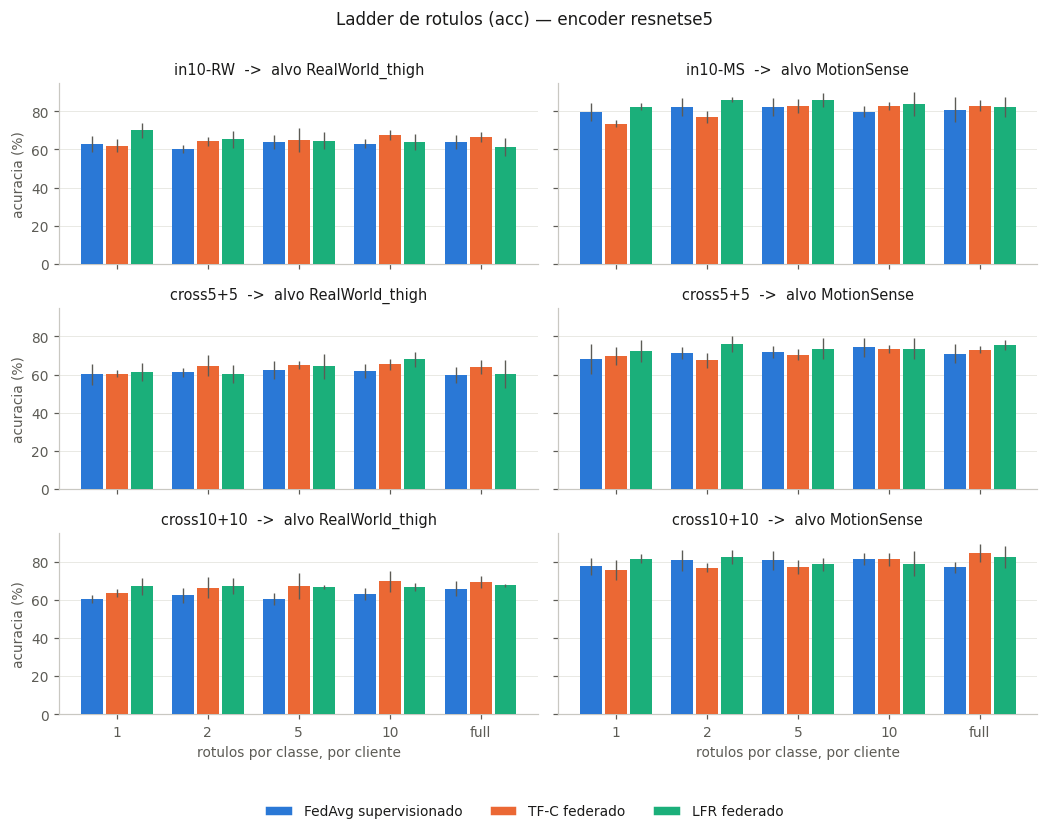

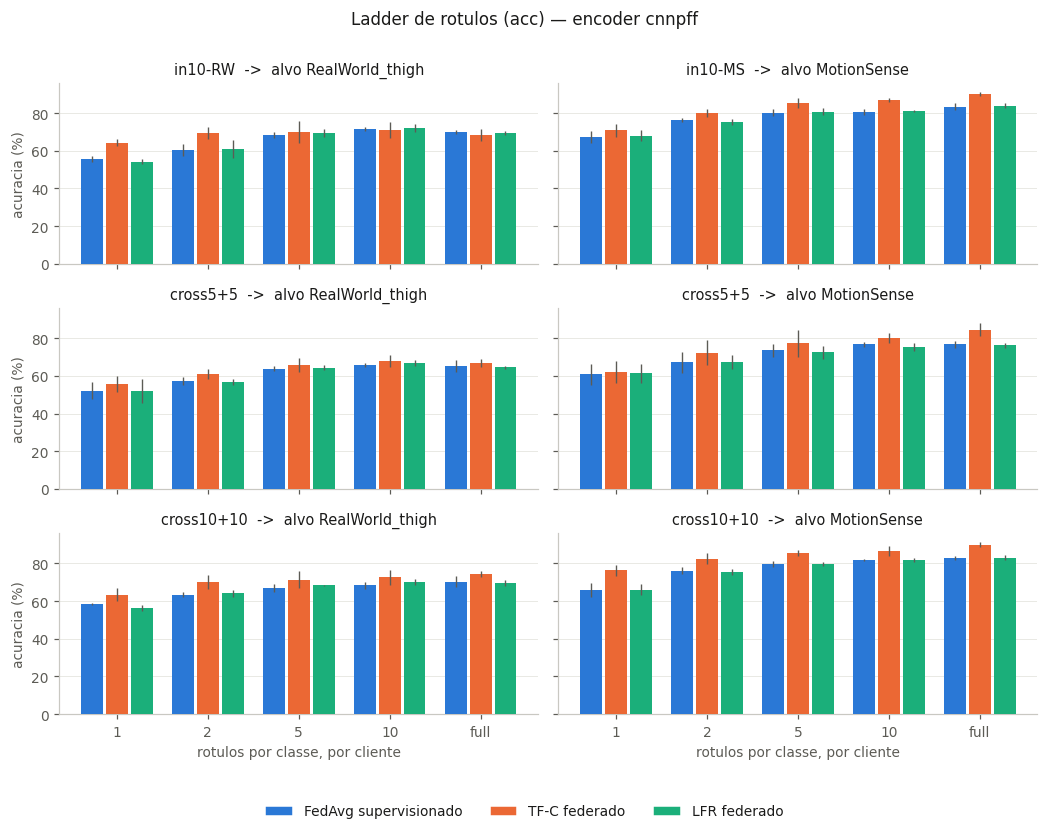

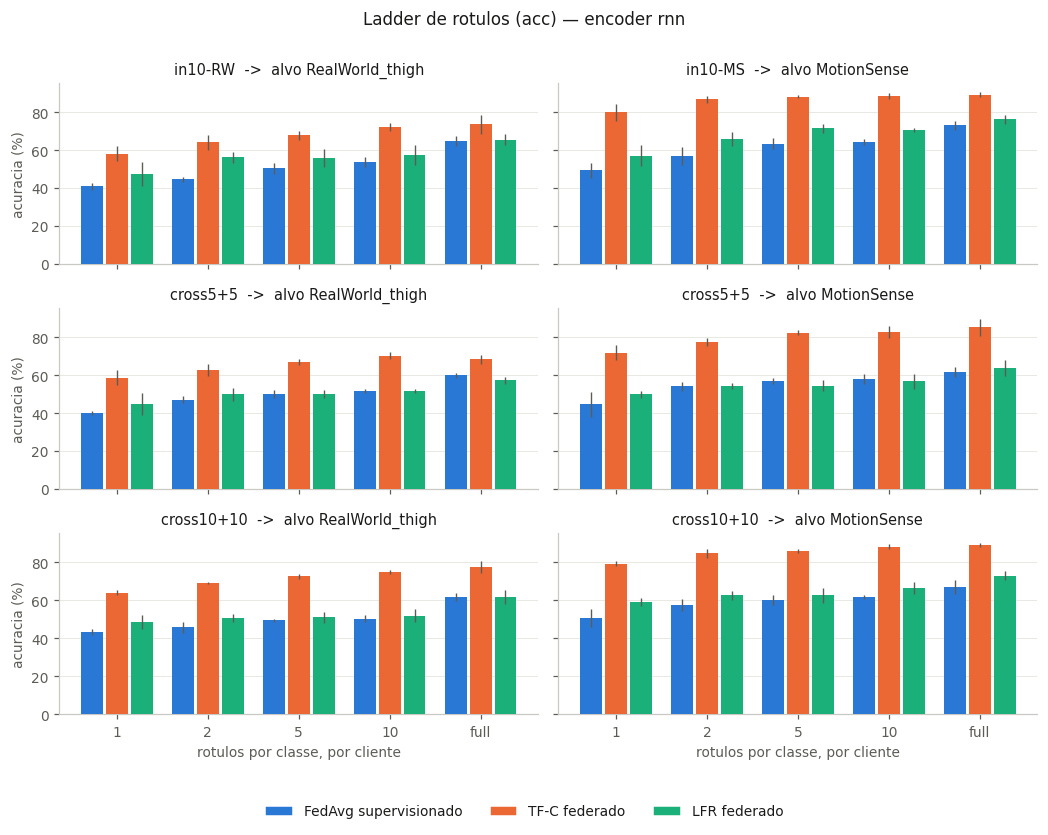

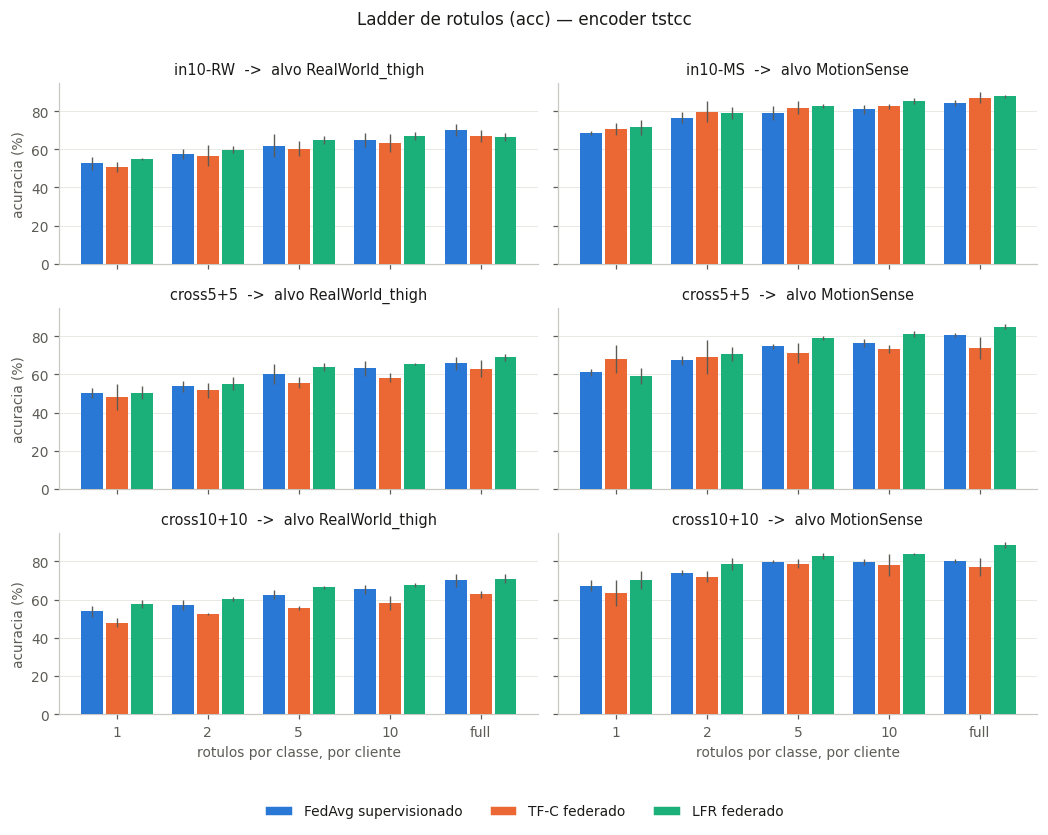

In [12]:
d = dados.assign(serie=dados.method)
for met, ylab in MET.items():
    for enc in ENCODERS:
        grade(d[d.encoder == enc], 'n_shots', ALL_SHOTS, met,
              f'Ladder de rotulos ({met}) — encoder {enc}', ylab,
              METHODS, CM, LABEL)

### 2.2 Por regime de rótulos — como os encoders se comparam entre si

Mesmos dados, eixo trocado. Aqui a leitura é *"com este orçamento de rótulos, qual
arquitetura entrega mais"* — e o `full` é o único degrau que o baseline vence com
folga em quase toda parte.

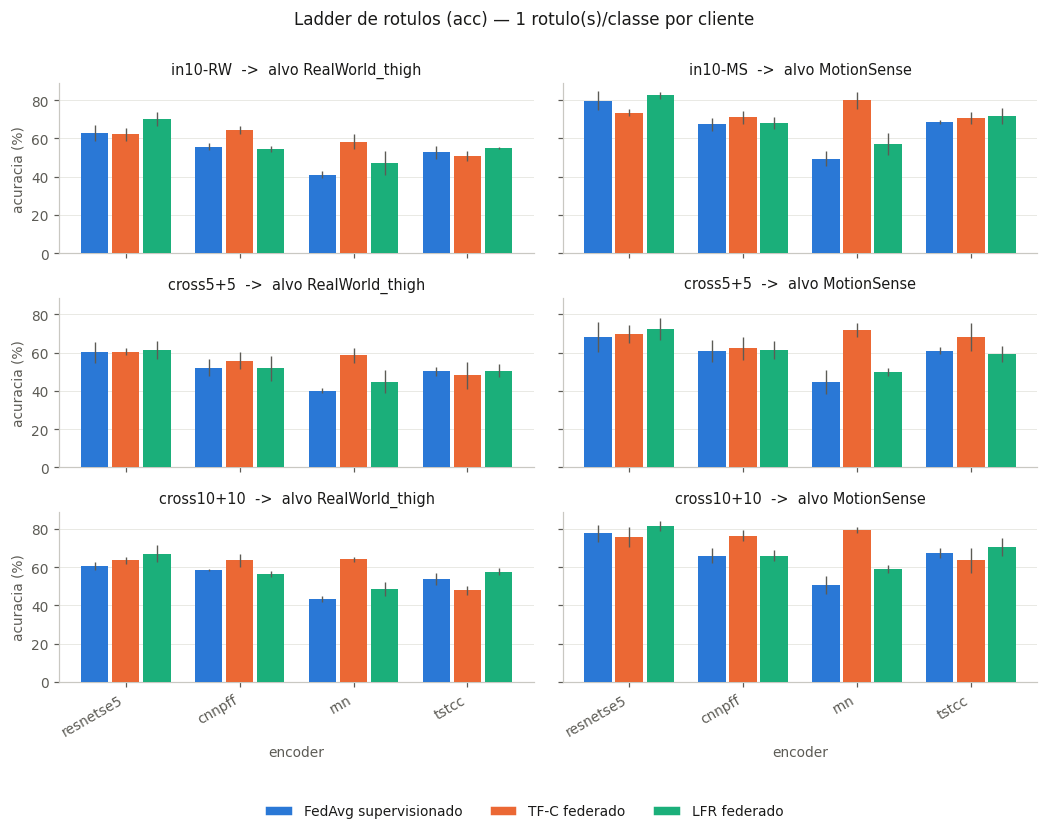

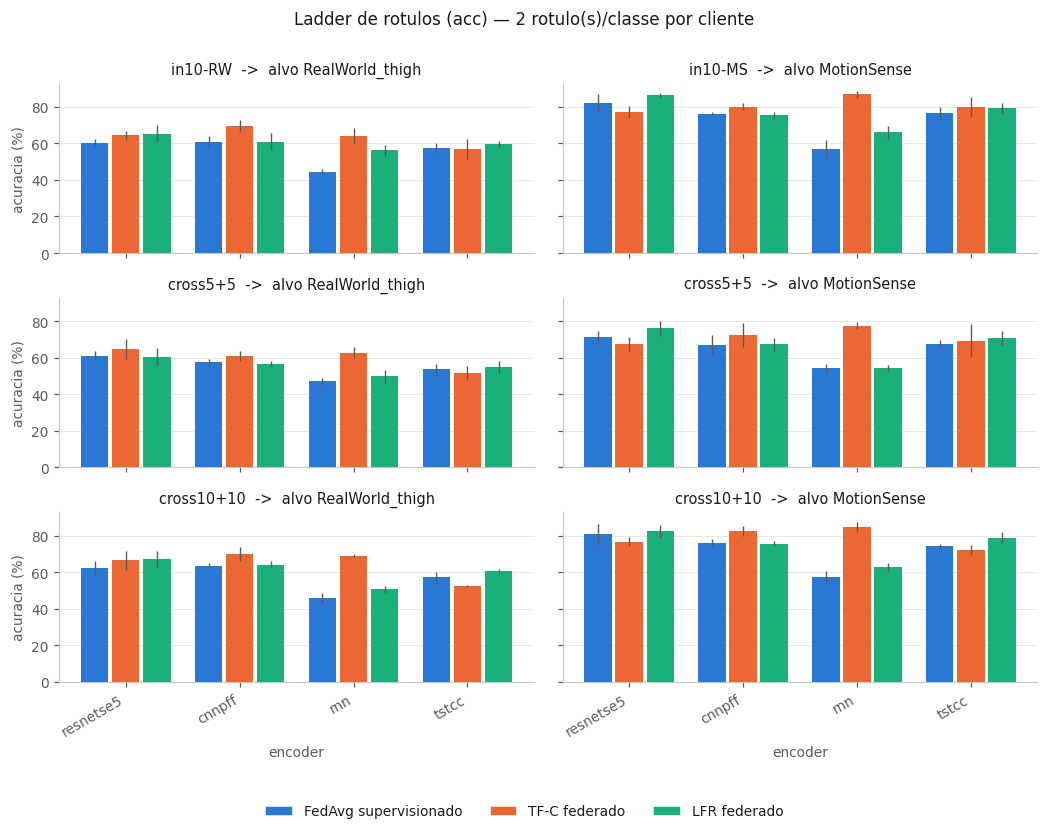

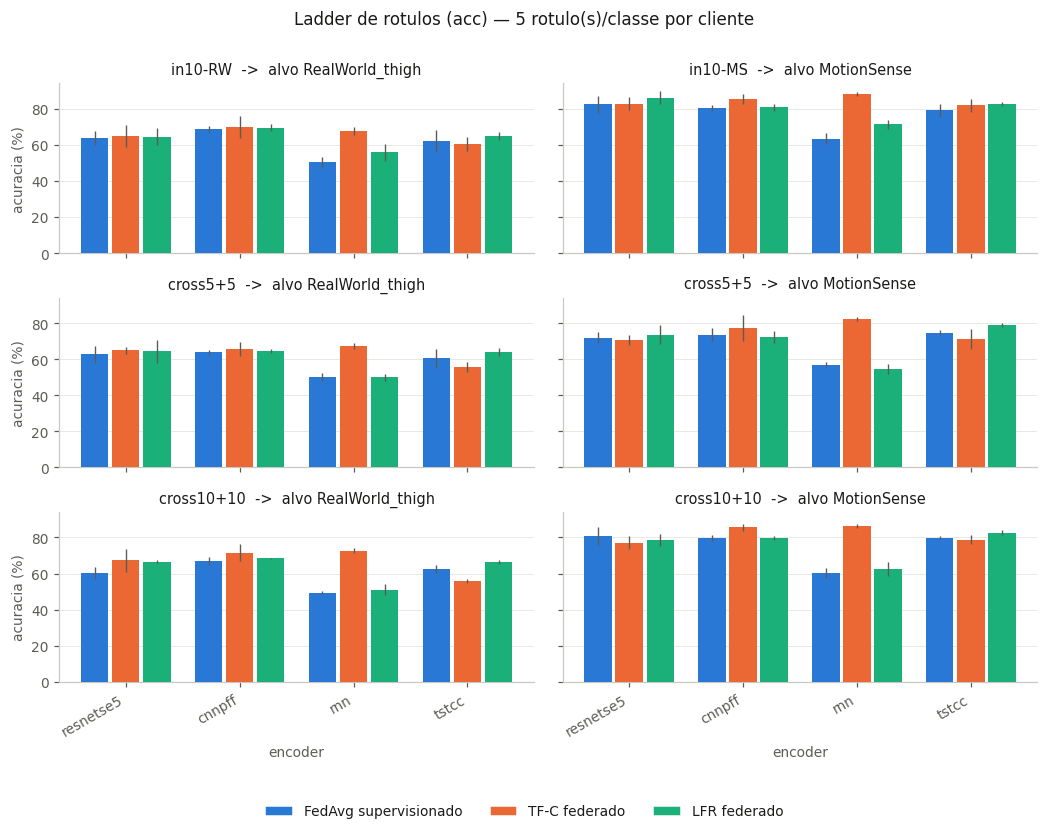

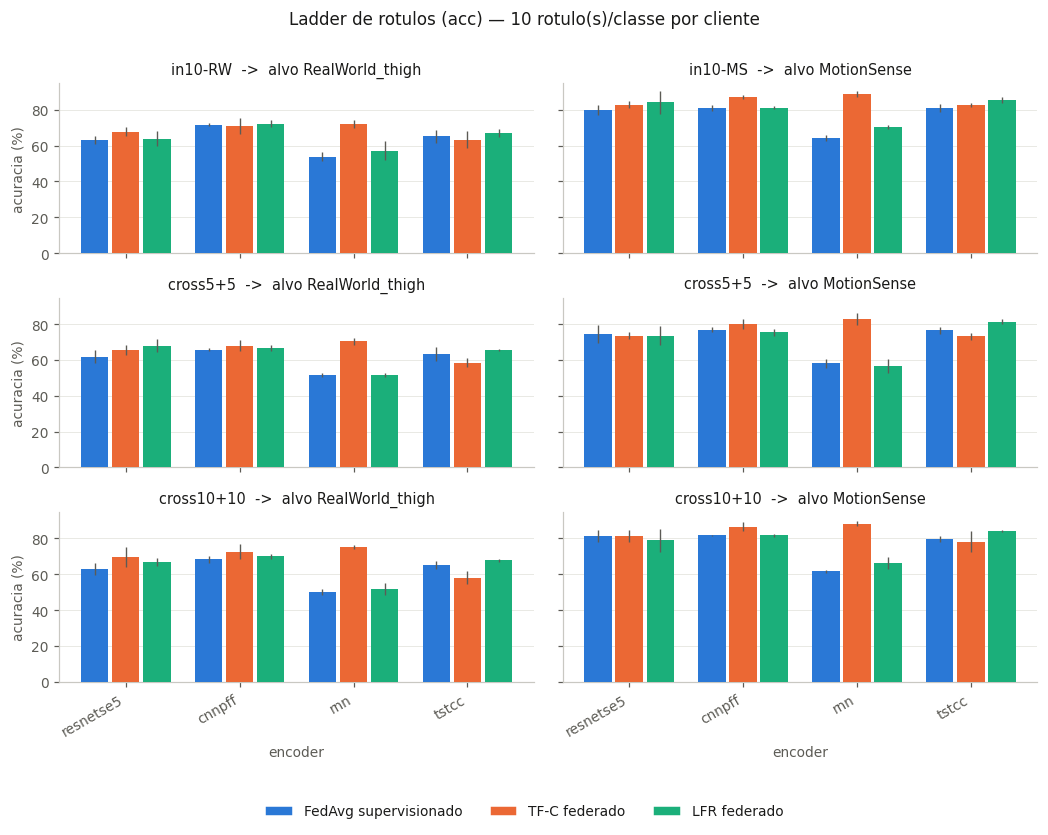

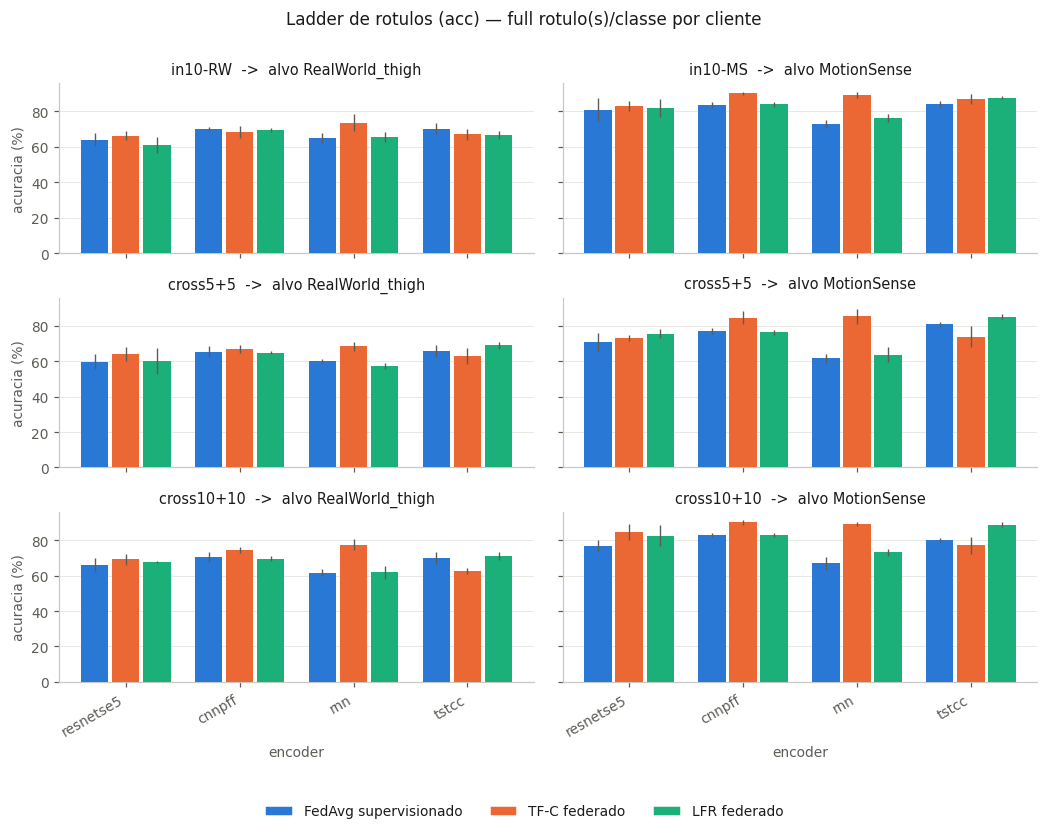

In [13]:
for met, ylab in MET.items():
    for s in ALL_SHOTS:
        grade(d[d.n_shots == s], 'encoder', ENCODERS, met,
              f'Ladder de rotulos ({met}) — {s} rotulo(s)/classe por cliente',
              ylab, METHODS, CM, LABEL, rot=30)

## 3. O ganho do SSL sobre o supervisionado (Δ)

A mesma coisa, agora com o baseline subtraído **dentro de cada seed** — não é média
menos média. Acima de zero, o pré-treino ajudou; abaixo, atrapalhou.

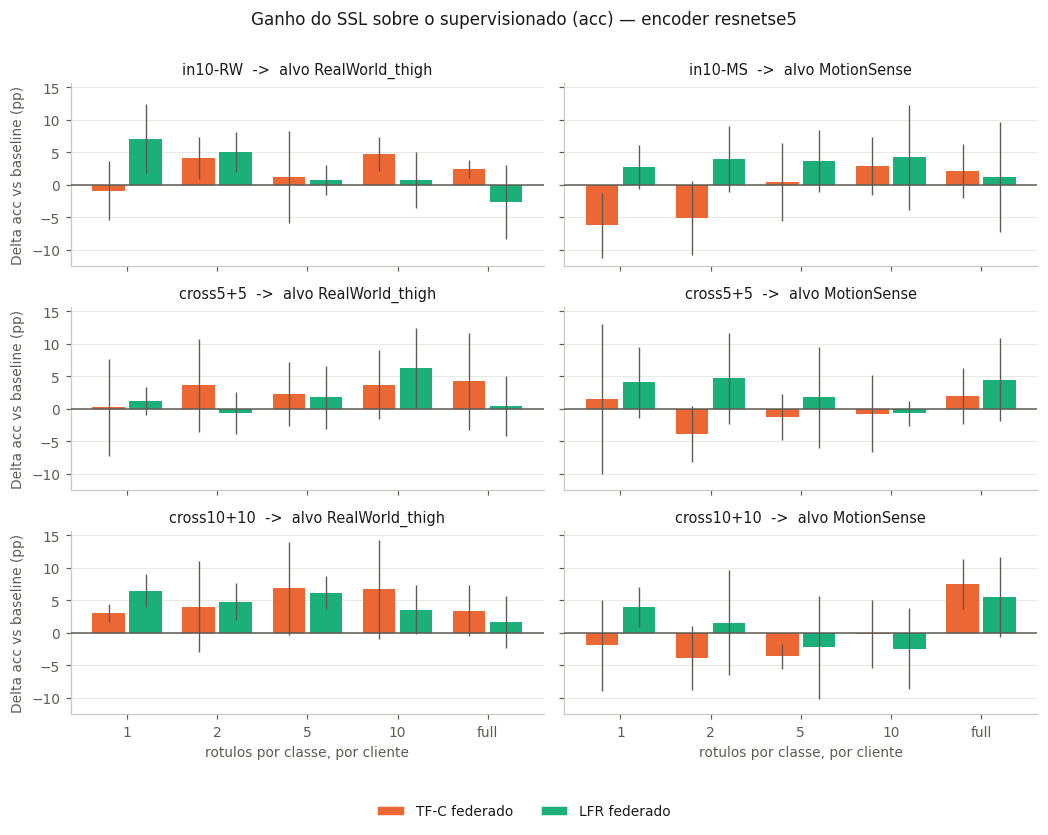

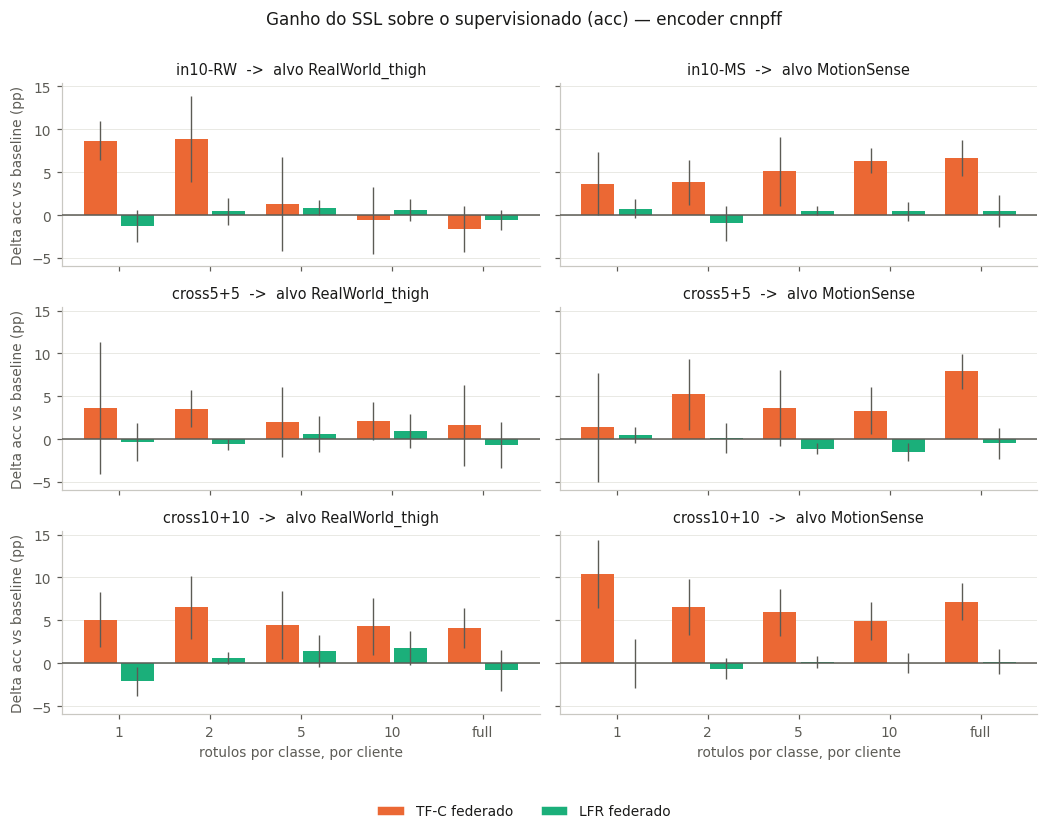

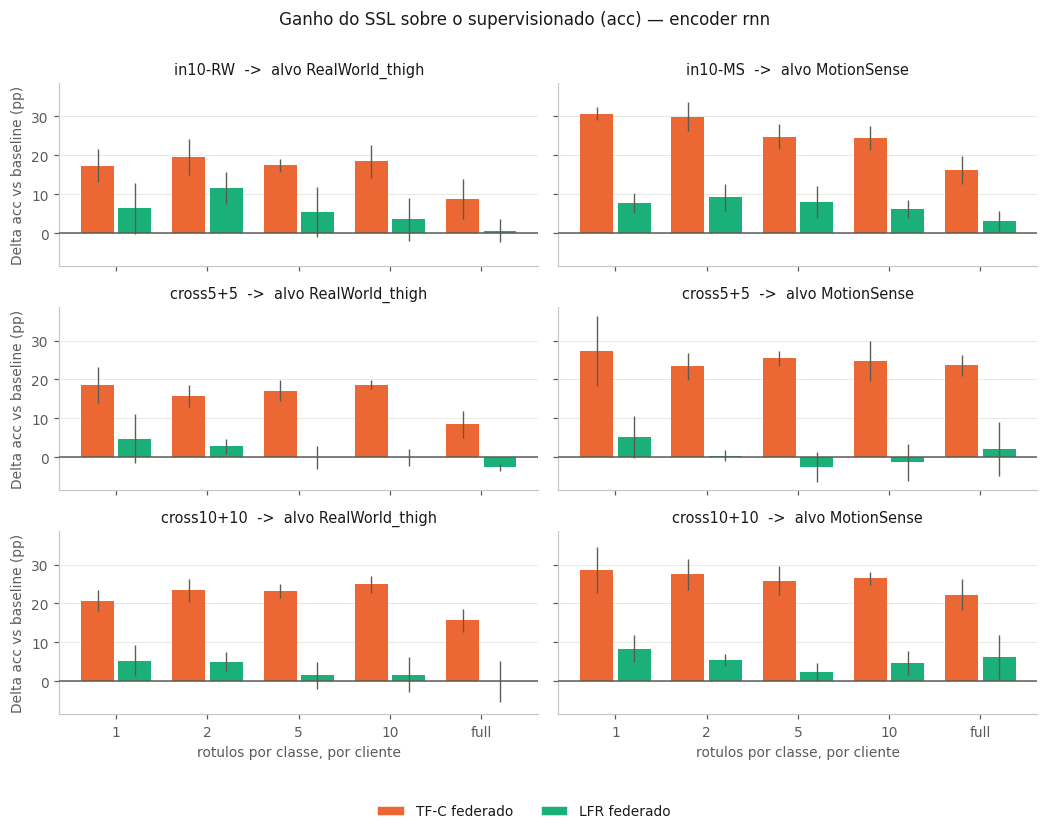

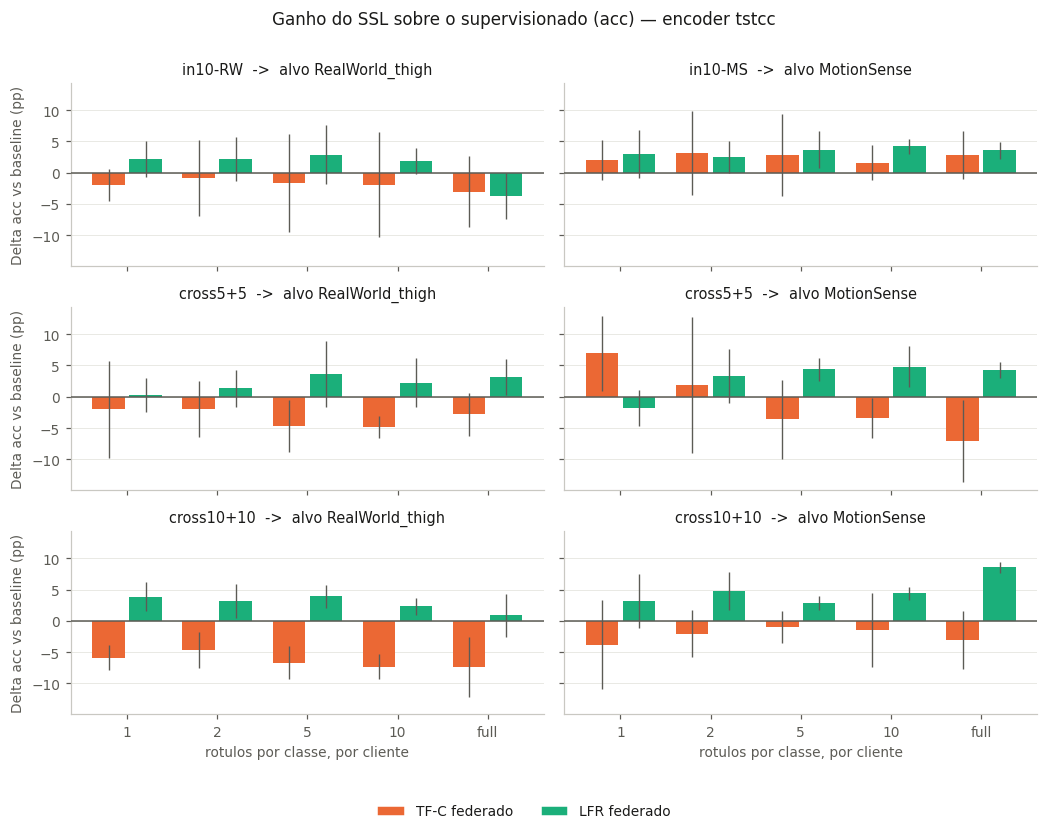

In [14]:
dl = delta.assign(serie=delta.method)
for met in MET:
    for enc in ENCODERS:
        grade(dl[dl.encoder == enc], 'n_shots', ALL_SHOTS, f'd_{met}',
              f'Ganho do SSL sobre o supervisionado ({met}) — encoder {enc}',
              f'Delta {met} vs baseline (pp)', SSL, CM, LABEL, zero=True)

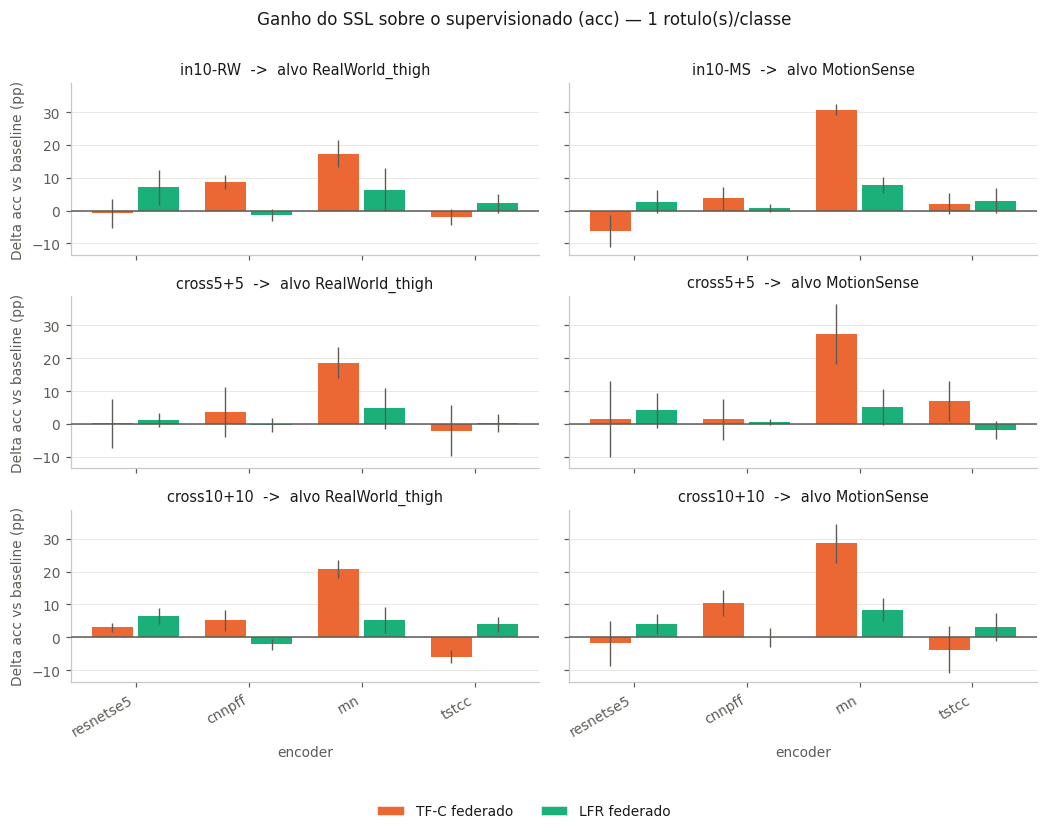

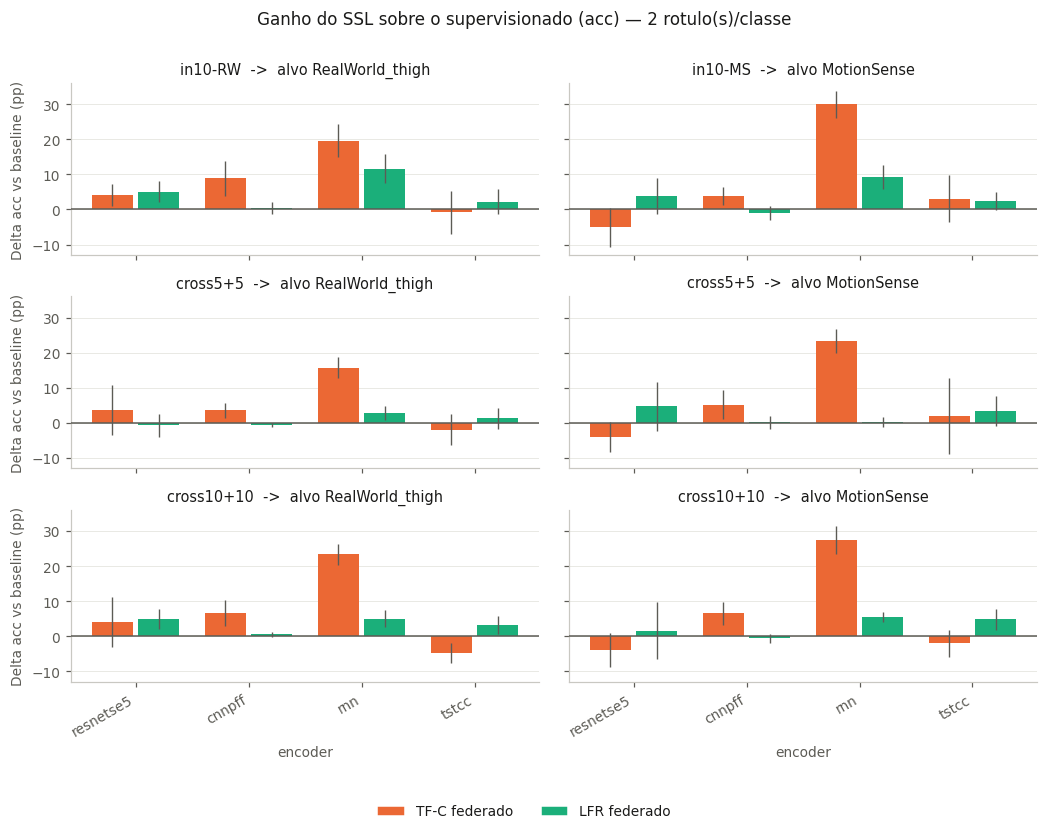

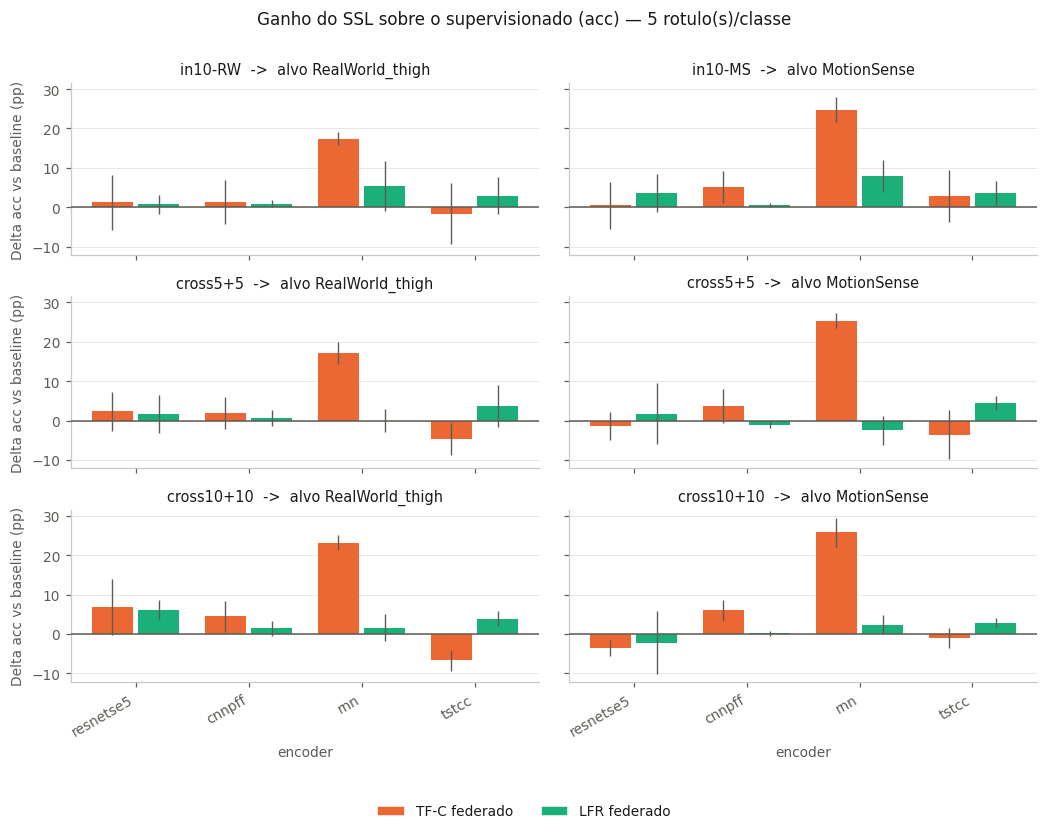

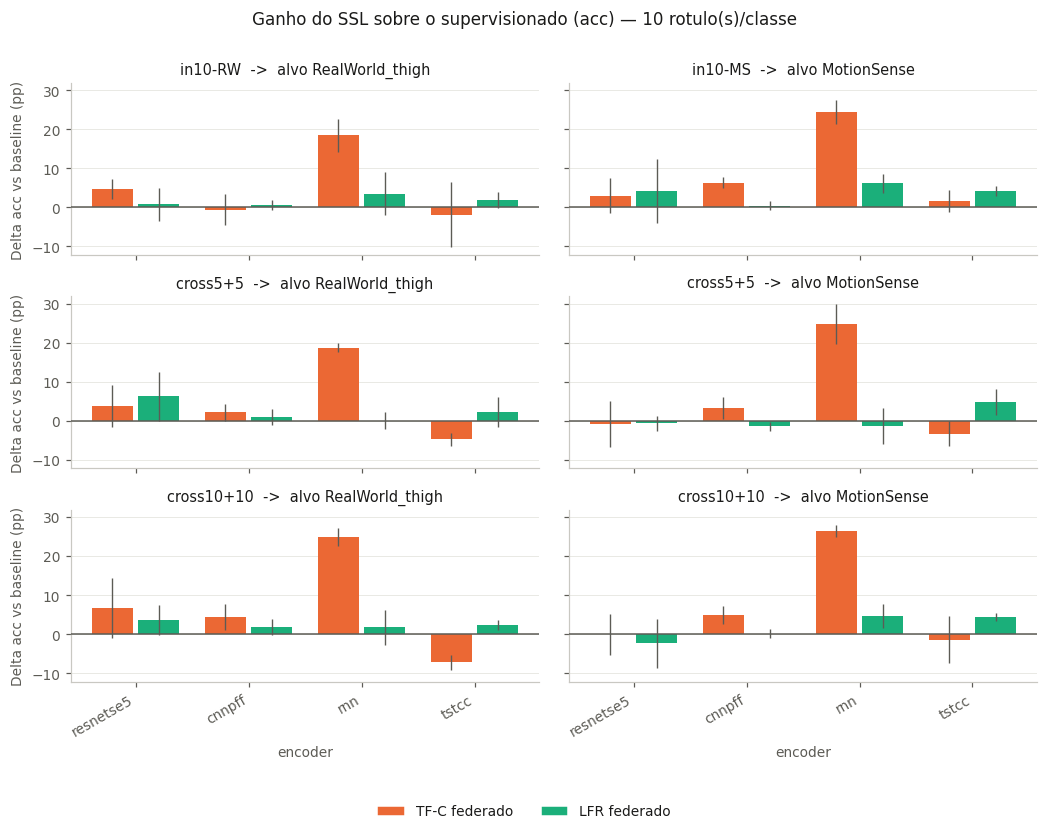

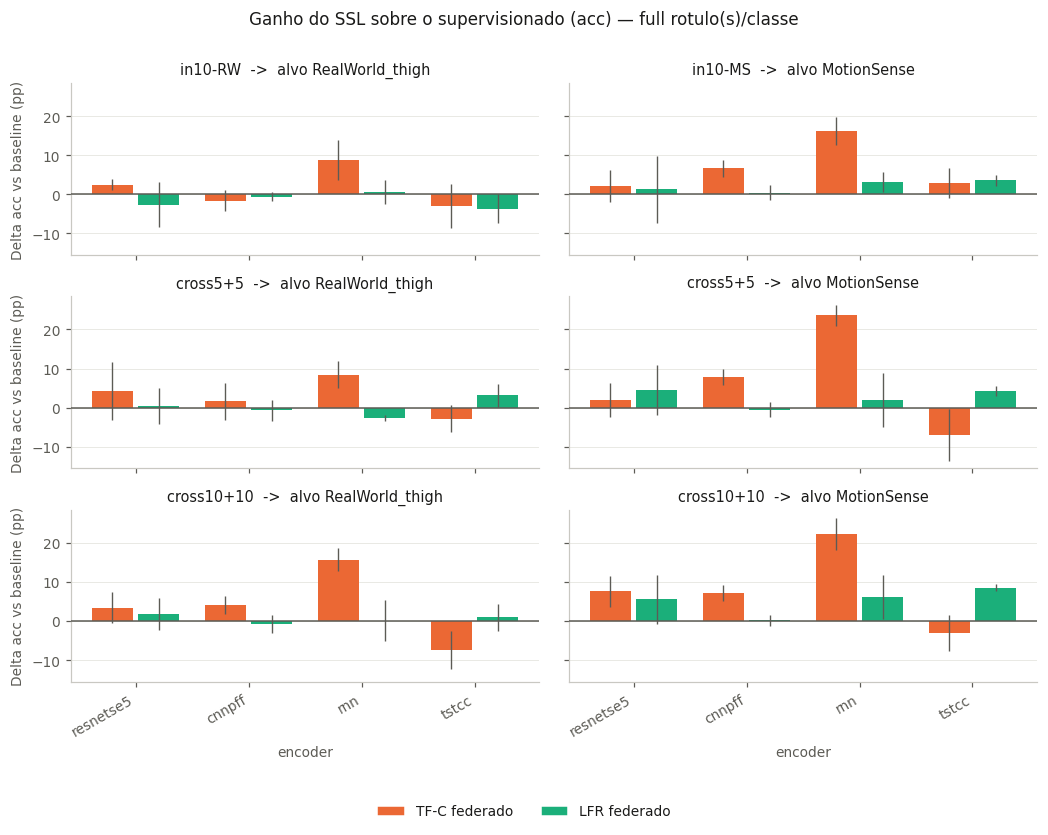

Delta medio (pp) por encoder x degrau, agregado sobre bracos e alvos —
CONFERENCIA da figura, nao substituto dela:


acc                        
                     1     2     5    10  full
method encoder                                
lfr    cnnpff     -0.4  -0.2   0.4   0.4  -0.3
       resnetse5   4.3   3.2   2.0   1.9   1.8
       rnn         6.3   5.7   2.5   2.4   1.6
       tstcc       1.8   2.9   3.6   3.3   2.8
tfc    cnnpff      5.5   5.8   3.7   3.4   4.3
       resnetse5  -0.7  -0.2   1.0   2.9   3.6
       rnn        23.9  23.3  22.3  22.9  15.9
       tstcc      -0.8  -0.8  -2.5  -2.9  -3.4

In [15]:
for met in MET:
    for s in ALL_SHOTS:
        grade(dl[dl.n_shots == s], 'encoder', ENCODERS, f'd_{met}',
              f'Ganho do SSL sobre o supervisionado ({met}) — {s} rotulo(s)/classe',
              f'Delta {met} vs baseline (pp)', SSL, CM, LABEL, zero=True, rot=30)

conferencia(dl, {m: f'd_{m}' for m in MET},
            'Delta medio (pp) por encoder x degrau, agregado sobre bracos e alvos —\n'
            'CONFERENCIA da figura, nao substituto dela:',
            index=['method', 'encoder'], columns='n_shots',
            ordem_cols=ALL_SHOTS)

## 4. Δ A — o ganho do SSL **dentro** do cenário cross-domain

Aqui o braço é fixo: só `cross5+5`, onde os clientes vêm de dois datasets diferentes.

É a leitura de **deployment**: *"vou operar uma federação com clientes de domínios
diferentes — o pré-treino ajuda?"* Não precisa de controle nenhum, e é o número que
interessa a quem vai usar o sistema.

Um painel por alvo, porque o custo do shift não é simétrico entre os dois.

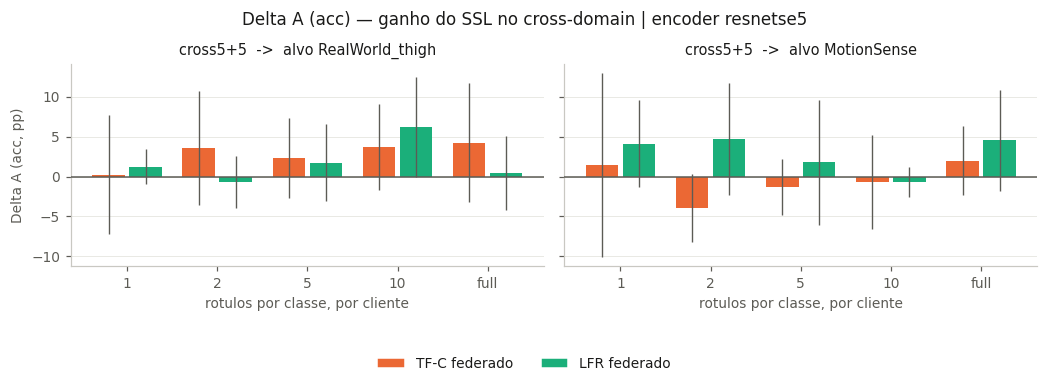

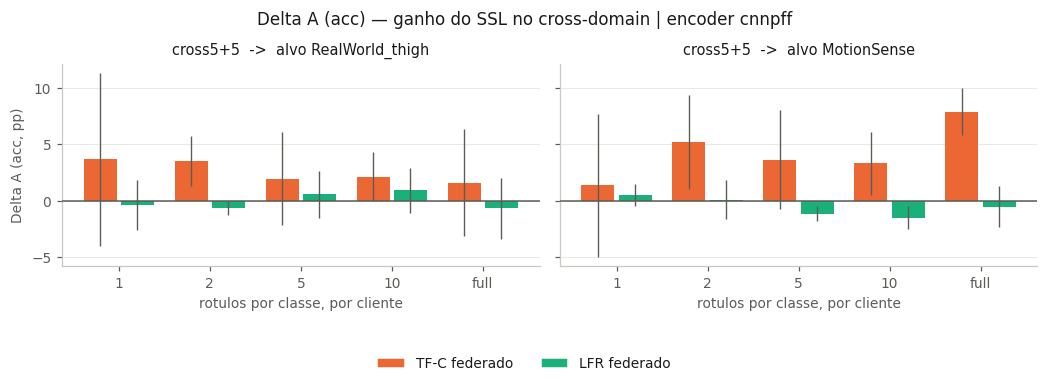

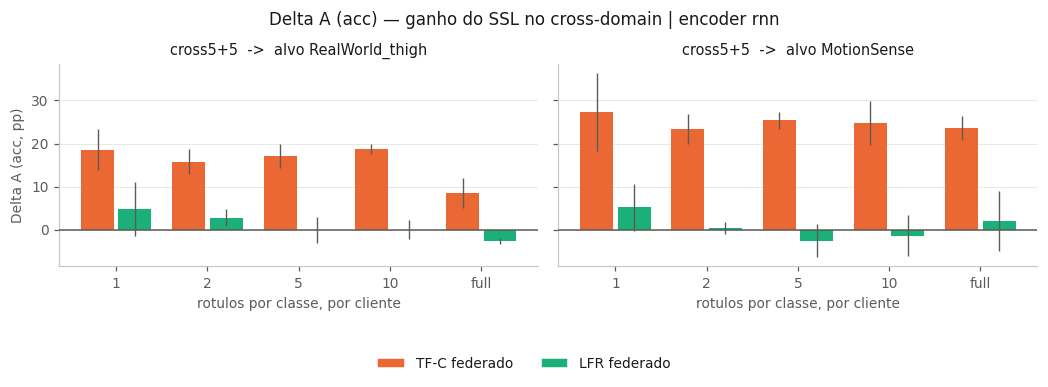

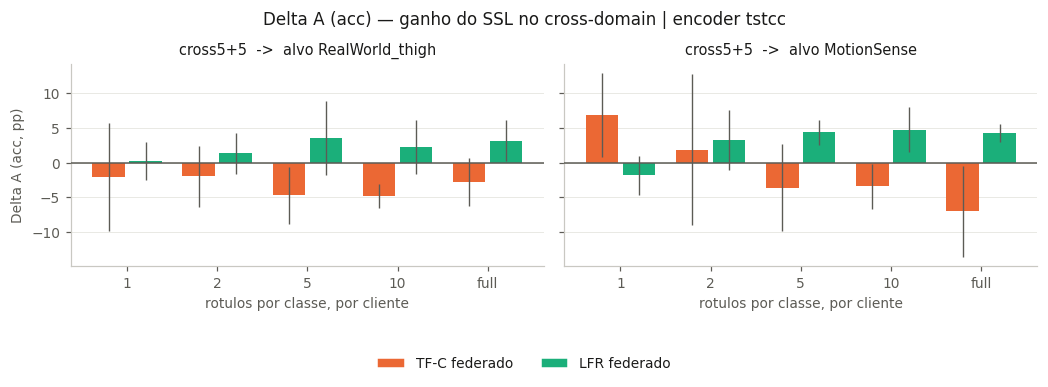

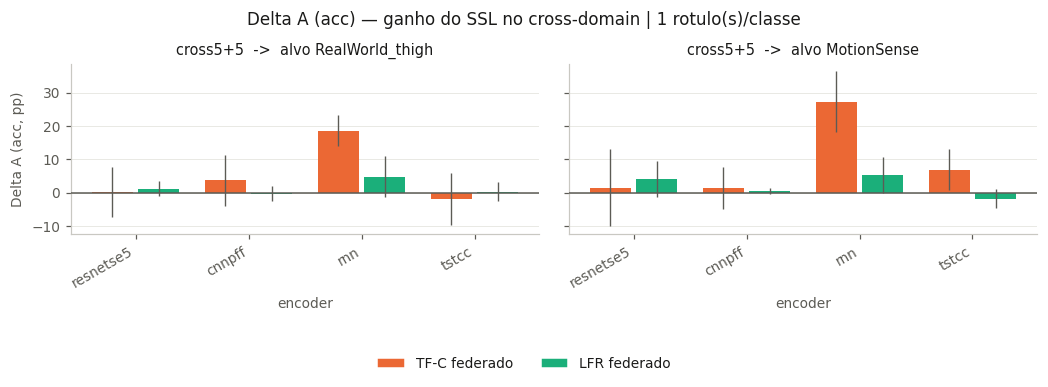

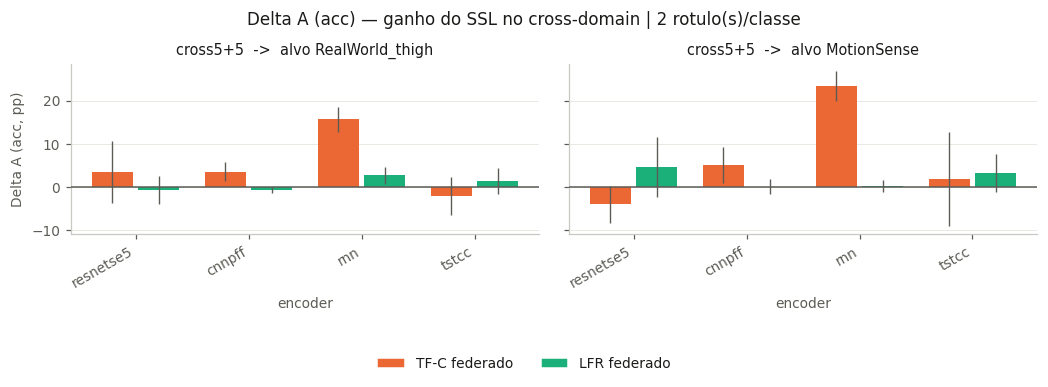

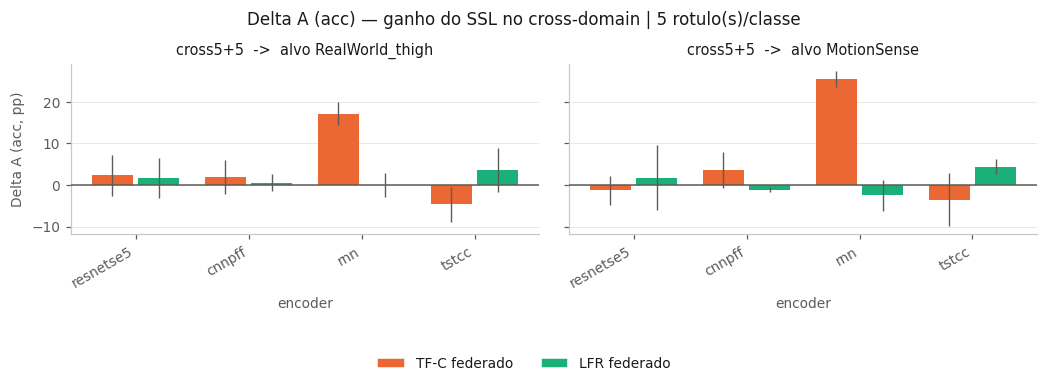

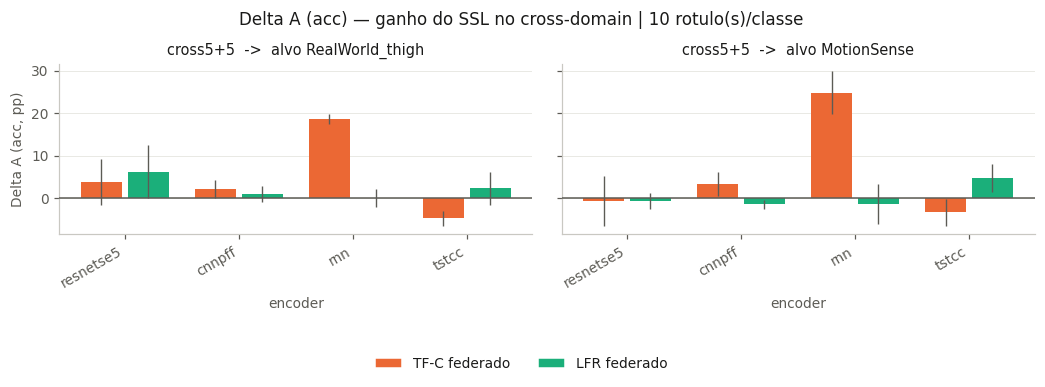

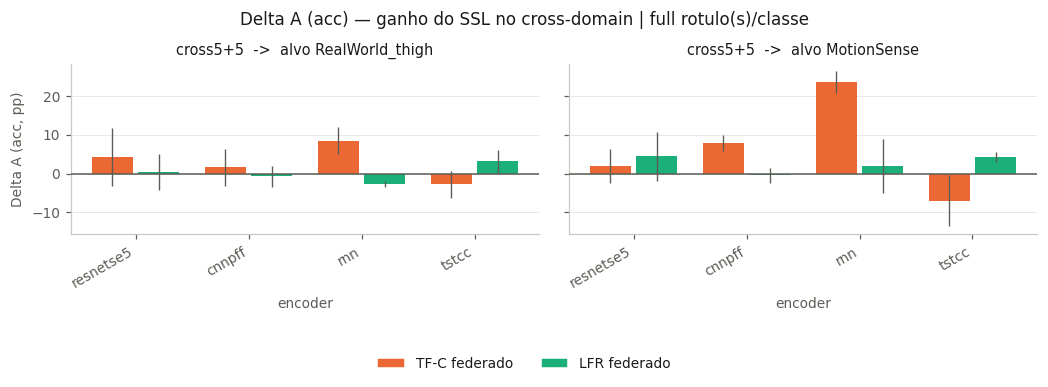

In [16]:
FAC_A = [(C55, 'RealWorld_thigh'), (C55, 'MotionSense')]

for met in MET:
    for enc in ENCODERS:
        grade(dl[dl.encoder == enc], 'n_shots', ALL_SHOTS, f'd_{met}',
              f'Delta A ({met}) — ganho do SSL no cross-domain | encoder {enc}',
              f'Delta A ({met}, pp)', SSL, CM, LABEL, facetas=FAC_A, zero=True,
              altura=2.8)

for met in MET:
    for s in ALL_SHOTS:
        grade(dl[dl.n_shots == s], 'encoder', ENCODERS, f'd_{met}',
              f'Delta A ({met}) — ganho do SSL no cross-domain | {s} rotulo(s)/classe',
              f'Delta A ({met}, pp)', SSL, CM, LABEL, facetas=FAC_A, zero=True,
              rot=30, altura=2.8)

## 5. Ganho no cross-domain − ganho no in-domain

*(era o "DiD" no notebook anterior)*

O Δ A sozinho **não** diz que o SSL ataca o domain shift. Se o pré-treino for
uniformemente melhor, o Δ A é grande sem que o custo do shift mude — é o caso do
`rnn`, onde o ganho no cross-domain é enorme mas o ganho no in-domain é ainda maior.
O SSL ali está consertando o **encoder**, não o **shift**.

Subtrair o ganho in-domain do ganho cross-domain isola isso:

```
ganho_cross  = acc(cross5+5, SSL) - acc(cross5+5, supervisionado)
ganho_in     = acc(in-domain, SSL) - acc(in-domain, supervisionado)
diferenca    = ganho_cross - ganho_in
```

**> 0** = o SSL rende mais justamente onde há shift. **≈ 0** = rende igual nos dois
cenários, e o ganho não tem nada a ver com domínio.

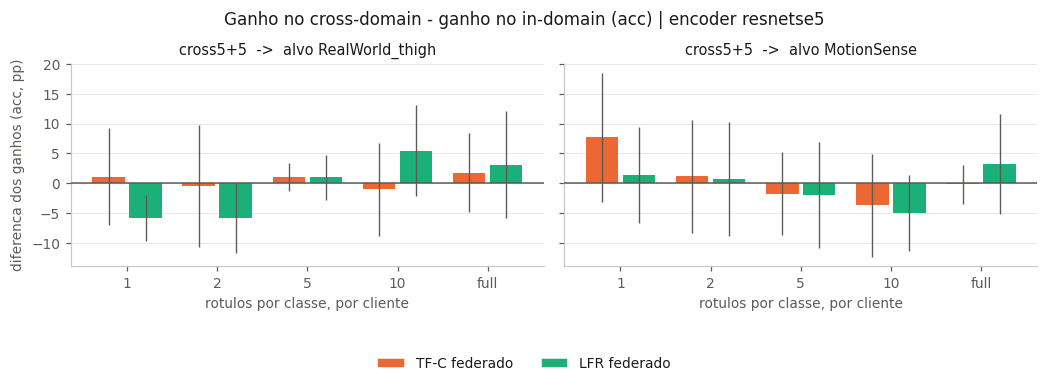

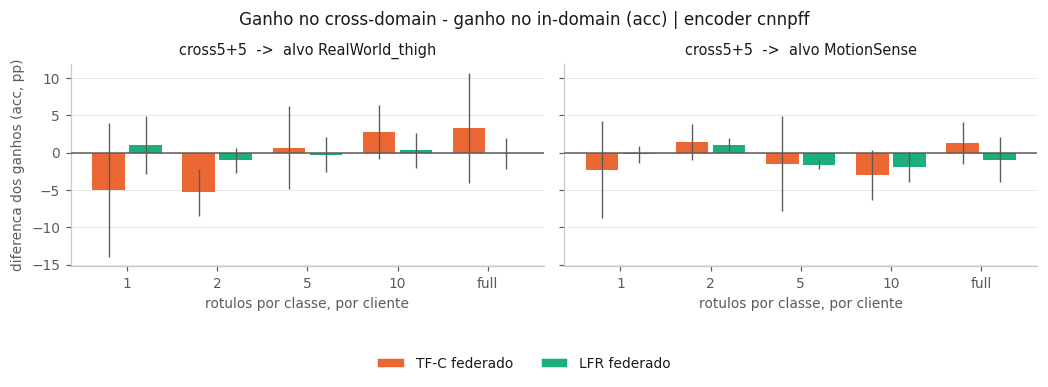

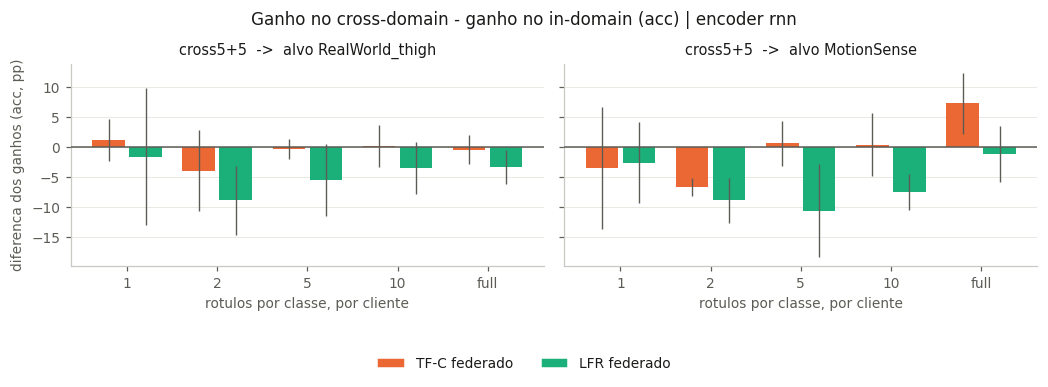

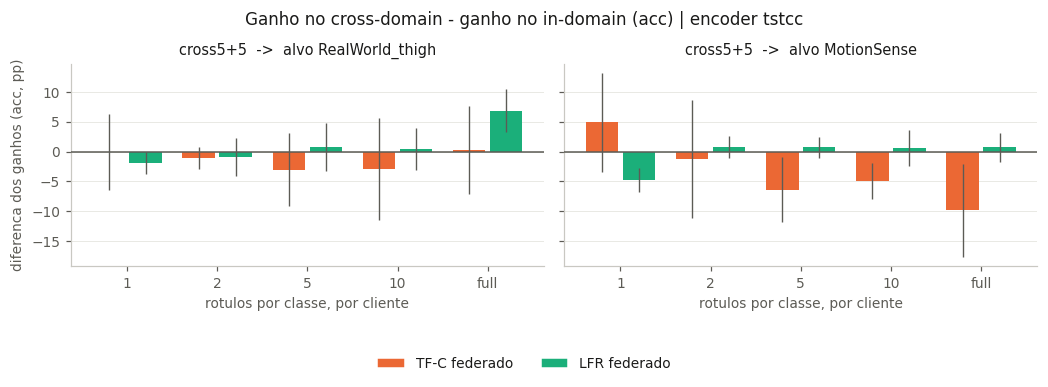

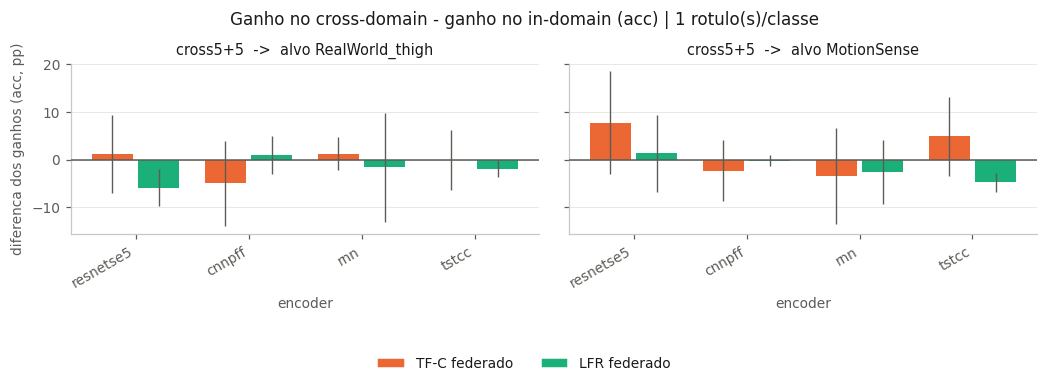

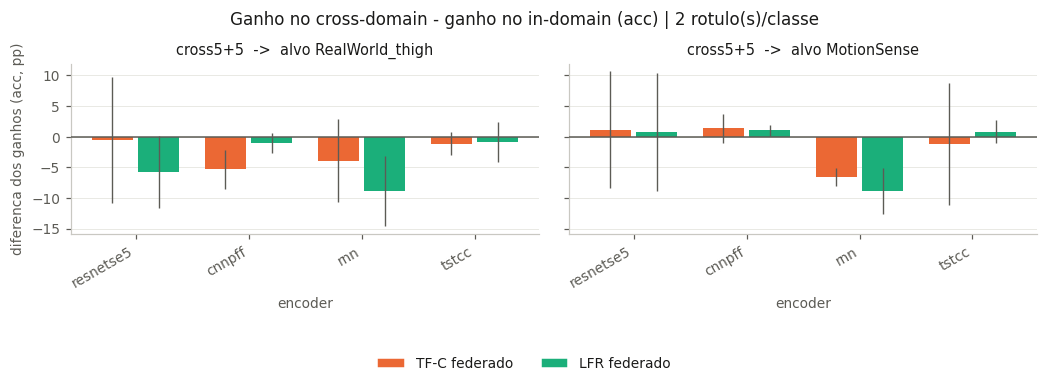

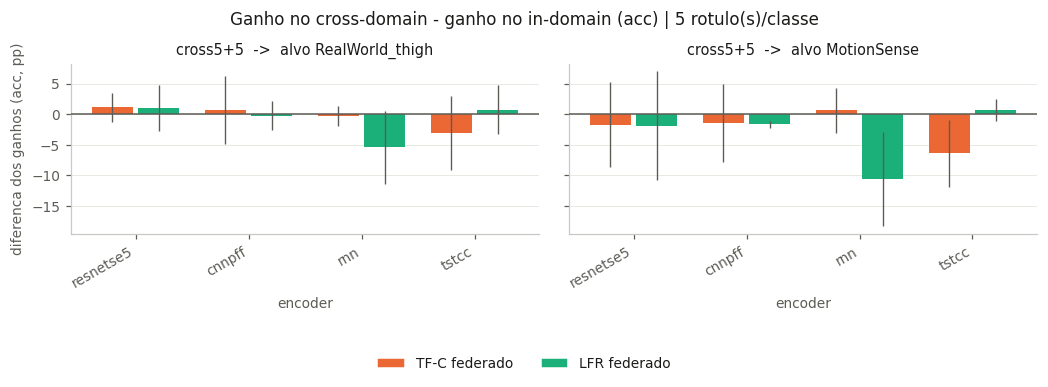

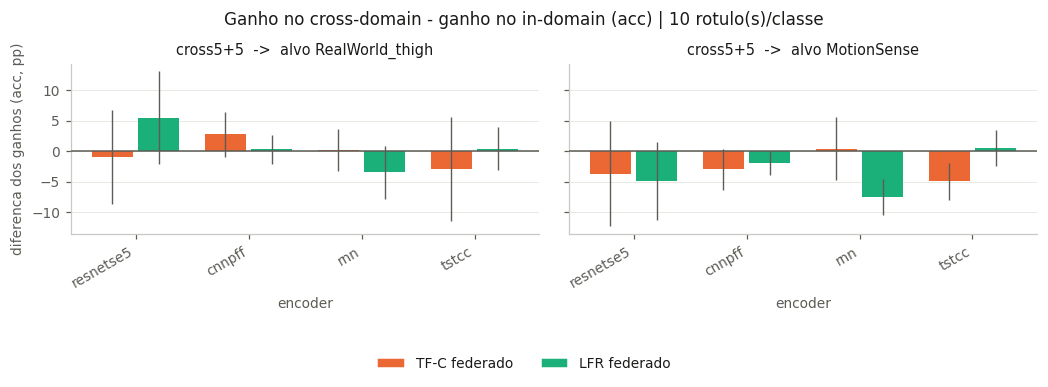

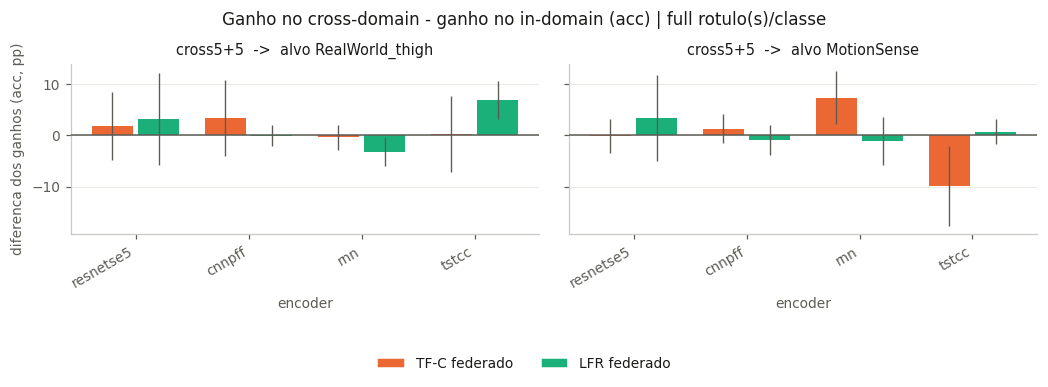

Media da diferenca (pp) — CONFERENCIA. Com 64 celulas, so o agregado
por encoder sustenta afirmacao; celula isolada e exploratoria.


acc                    
                    1    2    5   10 full
method encoder                           
lfr    cnnpff     0.4  0.0 -1.0 -0.8 -0.5
       resnetse5 -2.3 -2.5 -0.4  0.3  3.2
       rnn       -2.1 -8.9 -8.0 -5.5 -2.2
       tstcc     -3.3 -0.0  0.7  0.5  3.8
tfc    cnnpff    -3.6 -2.0 -0.4 -0.1  2.3
       resnetse5  4.4  0.3 -0.3 -2.3  0.8
       rnn       -1.1 -5.3  0.2  0.3  3.5
       tstcc      2.4 -1.2 -4.7 -3.9 -4.8

In [17]:
IDX = ['method', 'encoder', 'seed', 'n_shots', 'target']
dl2 = dl.assign(in_spec=dl.target.map(IN_SPEC))
COLS = [f'd_{m}' for m in MET]
cross = (dl2[dl2.spec == C55].set_index(IDX)[COLS]
         .rename(columns=lambda c: f'{c}_cross'))
indom = (dl2[dl2.spec == dl2.in_spec].set_index(IDX)[COLS]
         .rename(columns=lambda c: f'{c}_in'))
dif = pd.concat([cross, indom], axis=1).dropna()
for met in MET:
    dif[f'dif_{met}'] = dif[f'd_{met}_cross'] - dif[f'd_{met}_in']
dif = dif.reset_index()
dif['serie'] = dif.method
dif['spec'] = C55                      # so para reusar a `grade`; o painel e o alvo

for met in MET:
    for enc in ENCODERS:
        grade(dif[dif.encoder == enc], 'n_shots', ALL_SHOTS, f'dif_{met}',
              f'Ganho no cross-domain - ganho no in-domain ({met}) | encoder {enc}',
              f'diferenca dos ganhos ({met}, pp)', SSL, CM, LABEL, facetas=FAC_A,
              zero=True, altura=2.8)

for met in MET:
    for s in ALL_SHOTS:
        grade(dif[dif.n_shots == s], 'encoder', ENCODERS, f'dif_{met}',
              f'Ganho no cross-domain - ganho no in-domain ({met}) | {s} rotulo(s)/classe',
              f'diferenca dos ganhos ({met}, pp)', SSL, CM, LABEL, facetas=FAC_A,
              zero=True, rot=30, altura=2.8)

conferencia(dif, {m: f'dif_{m}' for m in MET},
            'Media da diferenca (pp) — CONFERENCIA. Com 64 celulas, so o agregado\n'
            'por encoder sustenta afirmacao; celula isolada e exploratoria.',
            index=['method', 'encoder'], columns='n_shots',
            ordem_cols=ALL_SHOTS)

## 6. O backbone precisa ter sido pré-treinado no domínio do alvo?

Nos braços anteriores, pré-treino e fine-tuning usavam **a mesma gente**. Aí não dá
para saber se o ganho vem de a representação ser boa ou de ela ter sido feita sob
medida para aquelas pessoas.

Aqui o fine-tuning é **idêntico** nos três casos (os mesmos 10 usuários do alvo, os
mesmos rótulos, as mesmas 150 rodadas). Só a origem do backbone muda:

| barra | pré-treino |
|---|---|
| **FedAvg supervisionado** | nenhum — pesos aleatórios |
| **próprio domínio** (lisa) | 10 usuários **do alvo** |
| **outro domínio** (hachurada) | 10 usuários **do outro dataset** |

As duas barras coloridas de cada método têm a **mesma cor de propósito** — é o mesmo
método, e cor identifica método em todo o notebook. O que as separa é a hachura.

Só os dois braços in-domain aparecem: pré-treinar "no outro domínio" não é definível
para um braço que já mistura os dois.

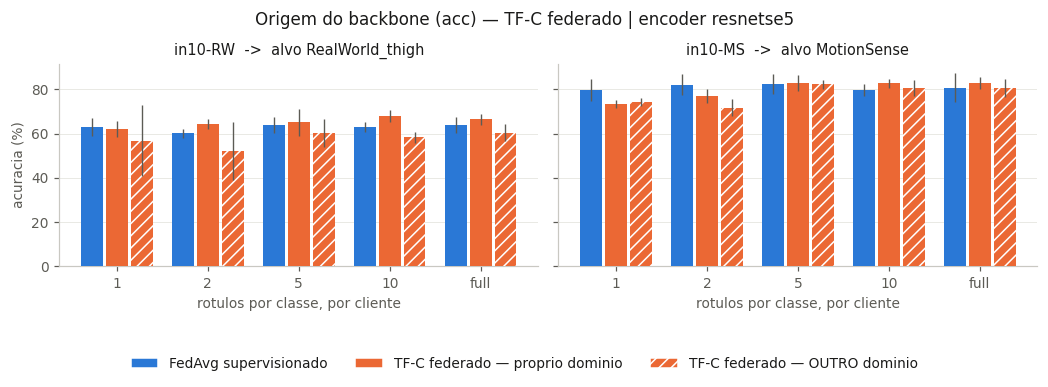

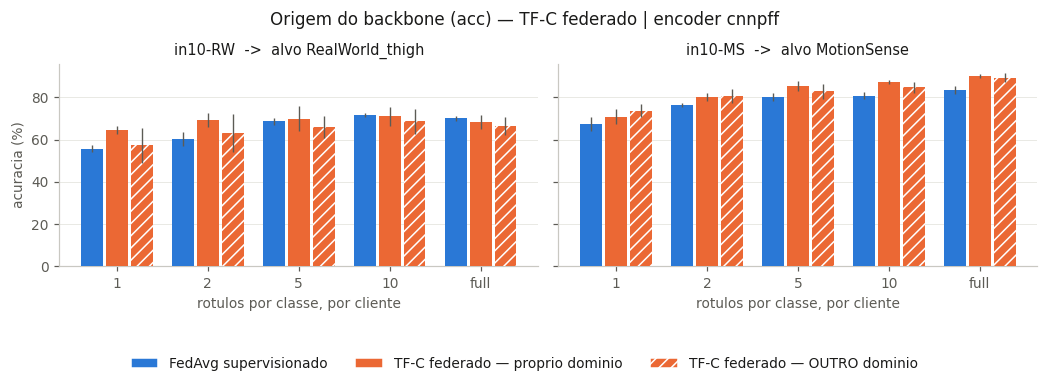

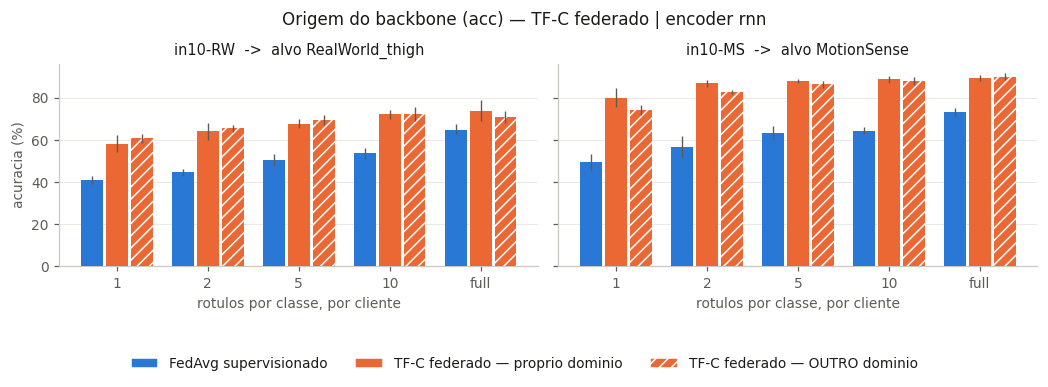

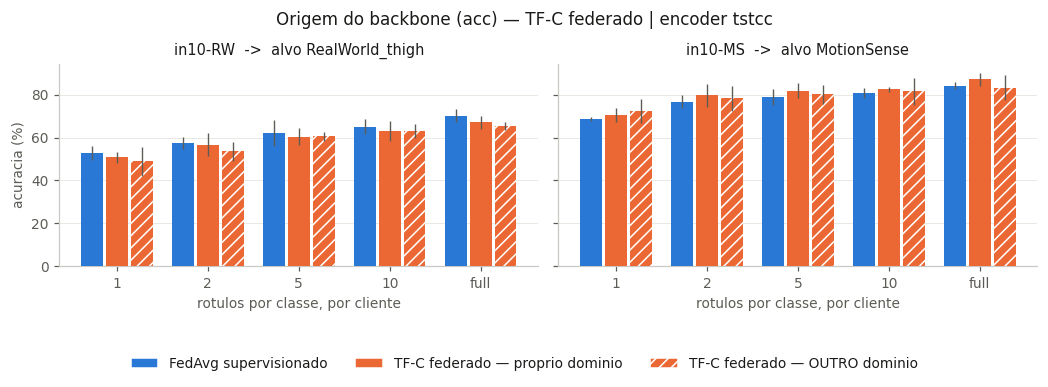

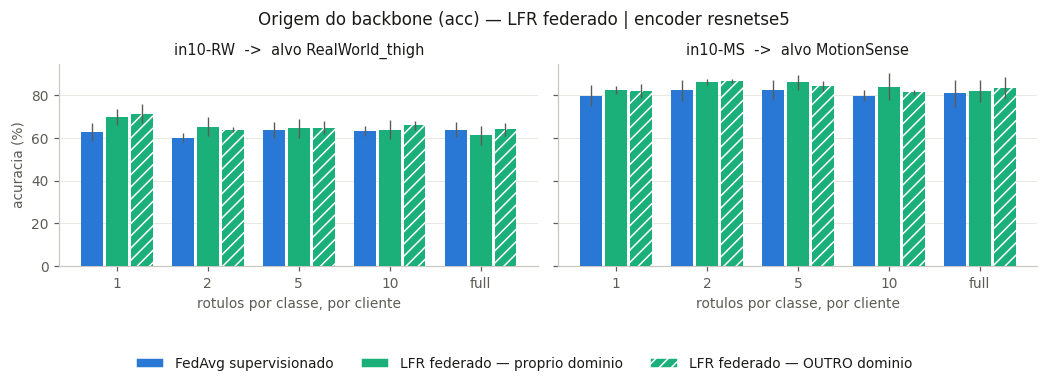

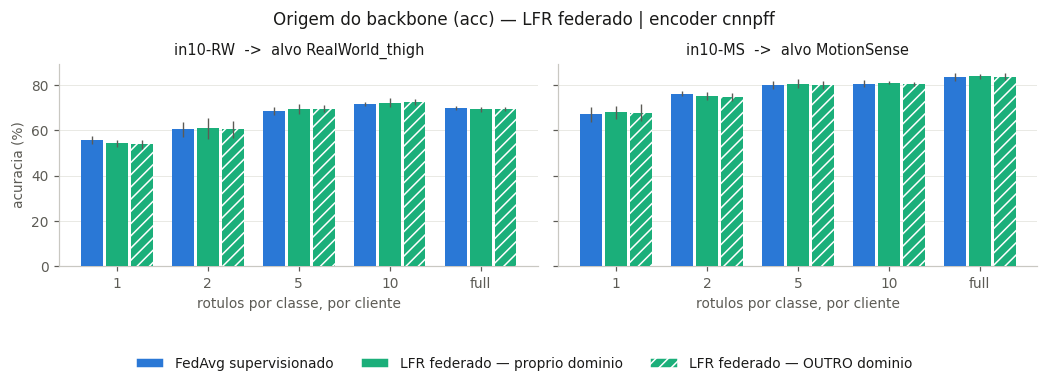

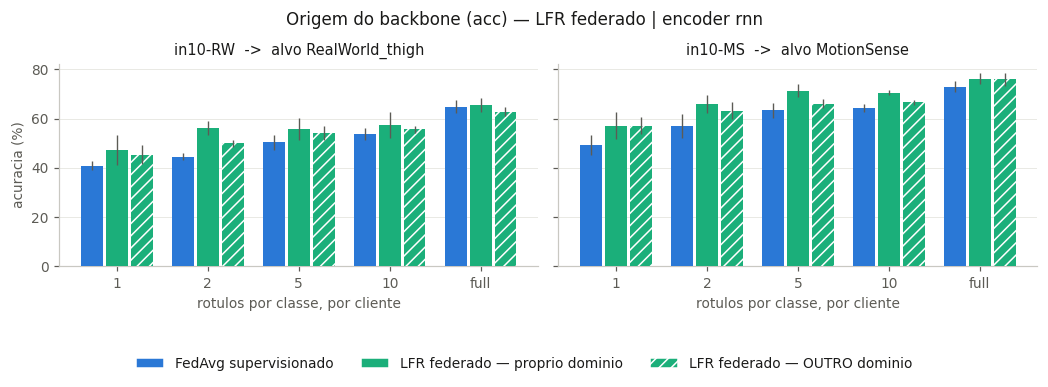

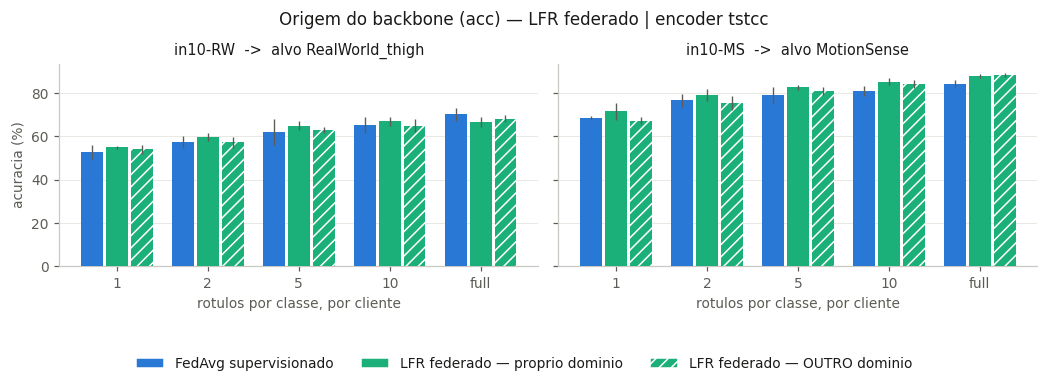

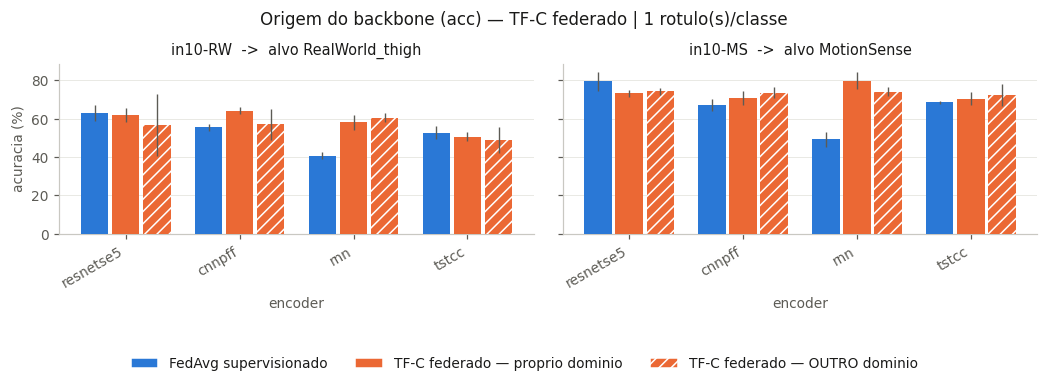

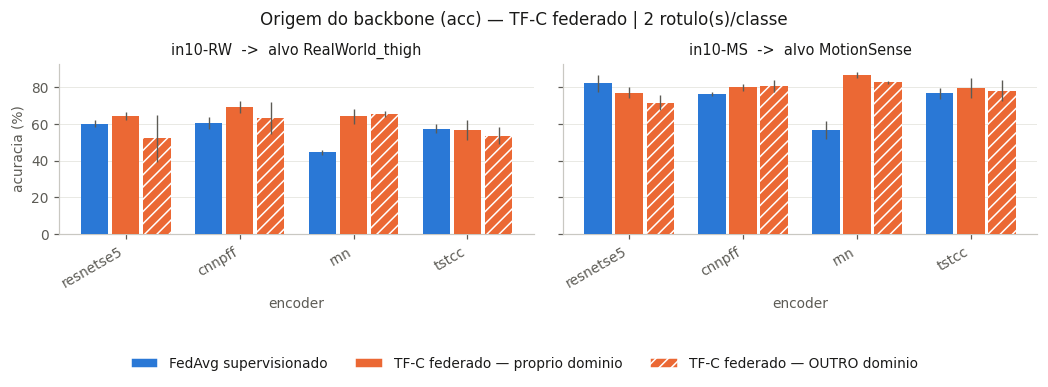

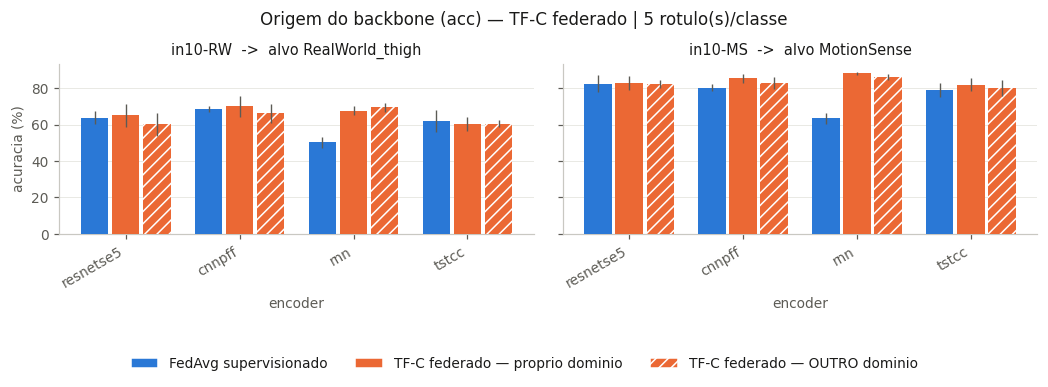

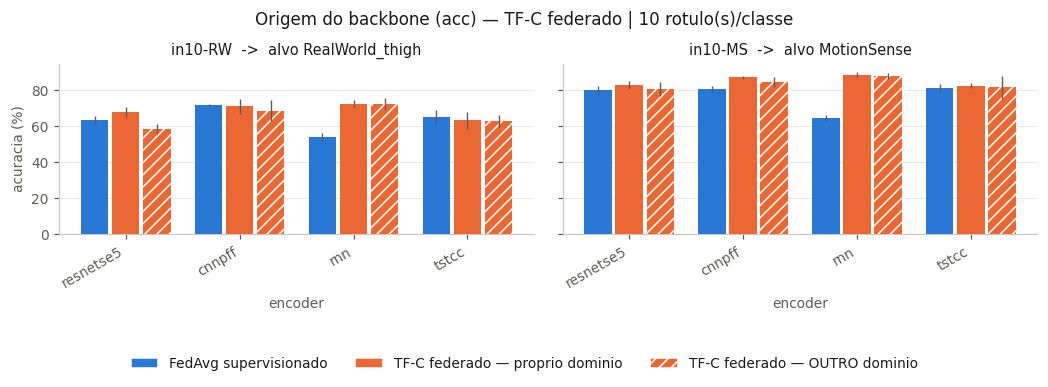

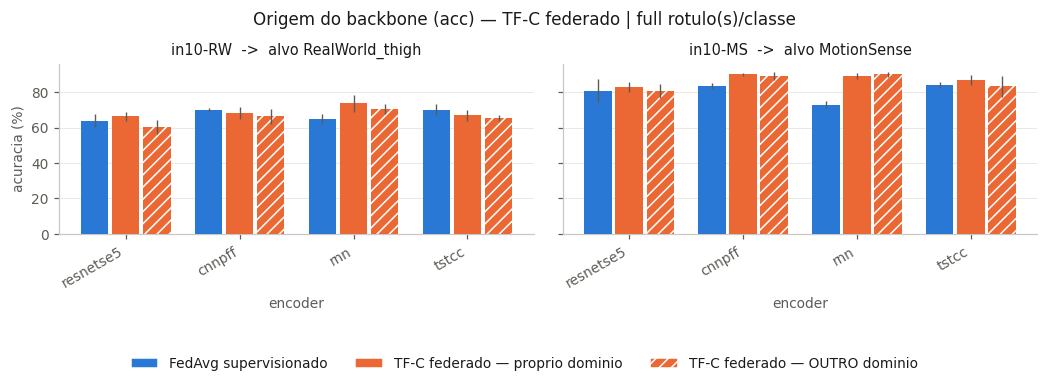

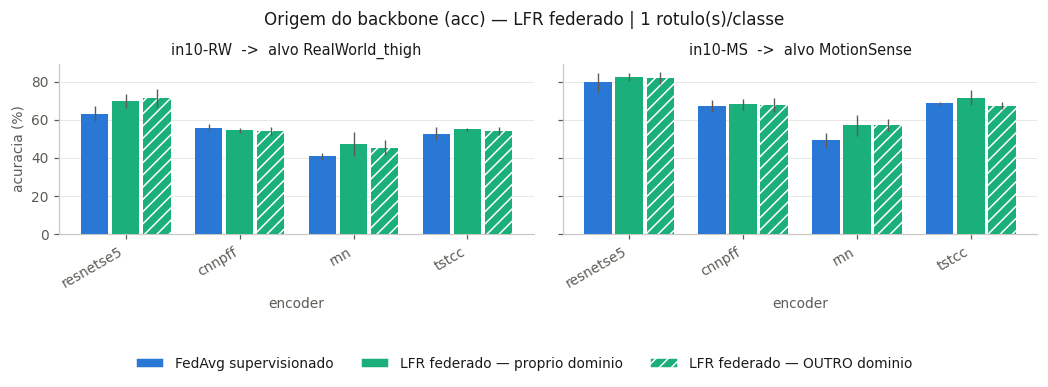

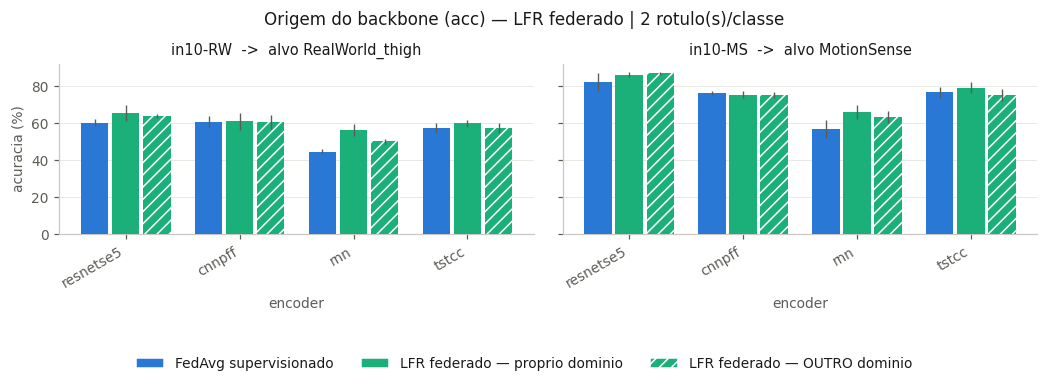

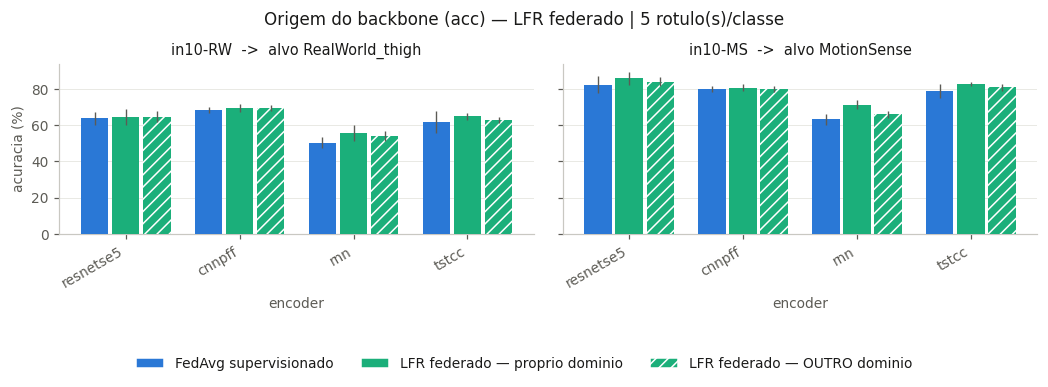

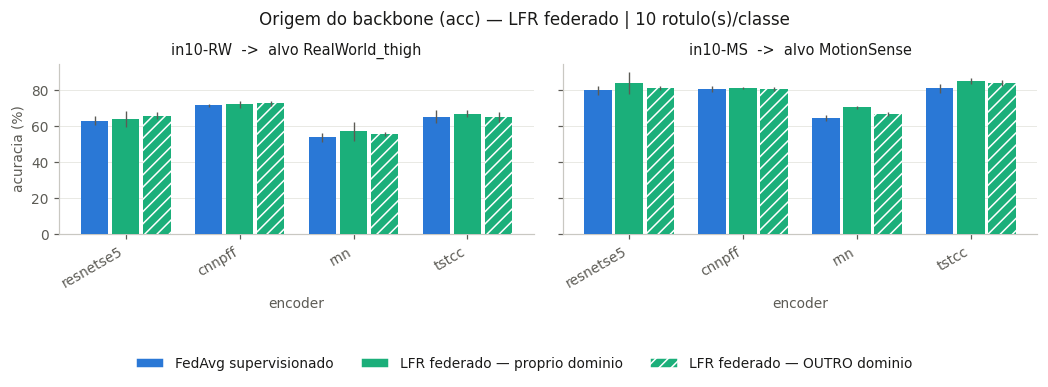

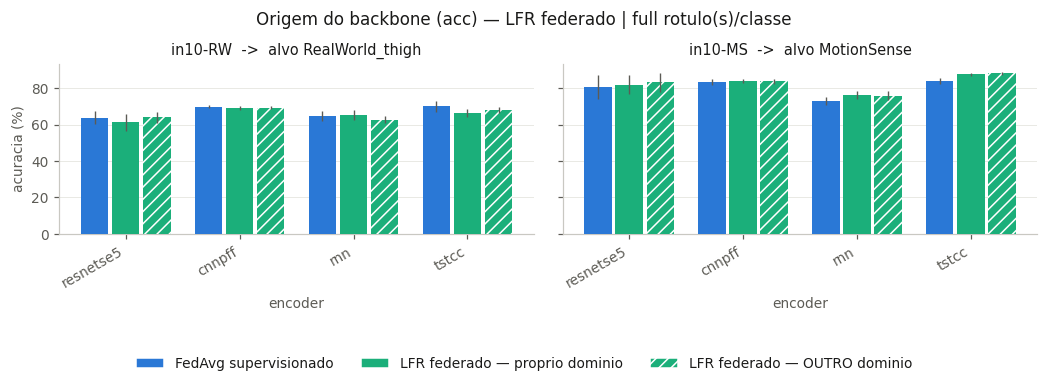

Media por origem do backbone — CONFERENCIA:


acc                                        
serie             lfr_outro lfr_proprio  none tfc_outro tfc_proprio
encoder   n_shots                                                  
cnnpff    1            60.9        61.1  61.4      65.5        67.6
          10           76.6        76.7  76.2      76.6        79.0
          2            67.8        68.1  68.4      72.0        74.7
          5            74.9        75.1  74.4      74.5        77.7
          full         76.6        76.7  76.8      77.9        79.2
resnetse5 1            76.6        76.2  71.3      65.5        67.7
          10           73.6        73.9  71.5      69.4        75.3
          2            75.3        75.7  71.2      61.9        70.7
          5            74.5        75.3  73.1      71.3        73.9
          full         73.7        71.7  72.4      70.5        74.7
rnn       1            51.2        52.1  45.0      67.5        69.1
          10           61.1        63.8  59.0      80.0        80.4
          2            56.6        61.1  50.7      74.0        75.5
          5            60.0        63.6  56.8      77.9        77.9
          full         69.4        70.8  68.9      80.4        81.5
tstcc     1            60.7        63.2  60.6      60.7        60.7
          10           74.5        76.1  73.0      72.3        72.9
          2            66.3        69.4  67.1      65.9        68.2
          5            72.0        73.8  70.5      70.3        71.2
          full         78.3        77.1  77.2      74.3        77.1

In [18]:
# `pre-device-*` = backbone feito no OUTRO dominio. O irmao `pre-single-*` (Exp. 2,
# backbone num cliente so) mora em outra pasta e responde outra pergunta.
xdev = pd.concat([pd.read_csv(f)
                  for f in sorted(XPART_DIR.glob('pre-device-*/*.csv'))],
                 ignore_index=True)
xdev['n_shots'] = xdev['n_shots'].astype(str)
xd = plato(xdev, int(xdev['round'].max())).reset_index()

SIMPLE = list(IN_SPEC.values())
FAC_O = [(sp, tg) for tg, sp in IN_SPEC.items()]

# Tres series por metodo: baseline (azul), pre-treino proprio (cor do metodo),
# pre-treino no outro dominio (mesma cor + hachura = codificacao secundaria).
orig = pd.concat([
    dados[(dados.method == 'none') & dados.spec.isin(SIMPLE)].assign(serie='none'),
    dados[dados.method.isin(SSL) & dados.spec.isin(SIMPLE)]
        .assign(serie=lambda x: x.method + '_proprio'),
    xd.assign(serie=lambda x: x.method + '_outro'),
], ignore_index=True)

def estilo_origem(m):
    ser = ['none', f'{m}_proprio', f'{m}_outro']
    return (ser,
            {'none': CM['none'], f'{m}_proprio': CM[m], f'{m}_outro': CM[m]},
            {f'{m}_outro': '///'},
            {'none': LABEL['none'],
             f'{m}_proprio': f'{LABEL[m]} — proprio dominio',
             f'{m}_outro': f'{LABEL[m]} — OUTRO dominio'})

# Por encoder. O filtro por encoder e OBRIGATORIO: o efeito e bimodal entre
# arquiteturas (o `rnn` ganha ~20 pp, o `resnetse5` perde), e uma media sobre os
# quatro devolveria uma barra que nao descreve arquitetura nenhuma.
for met, ylab in MET.items():
    for m in SSL:
        ser, cores, hat, rot = estilo_origem(m)
        for enc in ENCODERS:
            grade(orig[orig.serie.isin(ser) & (orig.encoder == enc)], 'n_shots',
                  ALL_SHOTS, met,
                  f'Origem do backbone ({met}) — {LABEL[m]} | encoder {enc}',
                  ylab, ser, cores, rot, facetas=FAC_O, hatch=hat, altura=2.8)

# Por regime de rotulos, com os encoders no eixo x.
for met, ylab in MET.items():
    for m in SSL:
        ser, cores, hat, rot = estilo_origem(m)
        for s in ALL_SHOTS:
            grade(orig[orig.serie.isin(ser) & (orig.n_shots == s)], 'encoder',
                  ENCODERS, met,
                  f'Origem do backbone ({met}) — {LABEL[m]} | {s} rotulo(s)/classe',
                  ylab, ser, cores, rot, facetas=FAC_O, hatch=hat, rot=30,
                  altura=2.8)

# `{m: m}` e nao `MET`: `conferencia` quer o NOME DA COLUNA, nao o rotulo do eixo.
conferencia(orig, {m: m for m in MET},
            'Media por origem do backbone — CONFERENCIA:',
            index=['encoder', 'n_shots'], columns='serie')

## 7. Ressalvas — ler antes de citar qualquer número daqui

1. **Correções múltiplas.** São dezenas de células por figura, cada uma com 4 seeds.
   Escolher a mais favorável e reportá-la é p-hacking. Só o agregado por encoder
   sustenta afirmação; a célula isolada gera hipótese, não a confirma.
2. **O `cross10+10` não é "dado estrangeiro vale tanto quanto dado próprio".** Ele
   tem 20 clientes contra 10 do `in10-RW`; não existe federação de 20 clientes só de
   RW_thigh (a base tem 10 usuários). O Δ dele é "acrescentar um segundo domínio".
3. **A diferença do §5 tem pouca dinâmica para medir.** O custo do shift no baseline
   vai de −0,7 a −9,8 pp, e só **um** par (resnetse5 / MotionSense) passa de −5. Com
   um ponto de alto custo, nem "mitiga" nem "não mitiga" é sustentável.
4. **F7.** Seleção few-shot na validação cheia (ver topo). Afeta todos os braços
   igualmente, então provavelmente não inverte um Δ — mas infla o nível absoluto.
5. **O §6 só cobre os braços in-domain**, pelo motivo dado lá.
6. **O degrau `full` do baseline vem de outra grade** (`fed_cross_device.csv`,
   filtrada em `local_epochs == 5`). Mesmo protocolo — R=150, budget 192, seeds 0–3 —,
   mas não foi executado no mesmo mutirão que o resto desta figura.